# GWASLAB VISUALIZATIONS

The results obtained from ldsc are unidirectional. Meaning that we have studied disease1-disease2 but not disease2-disease1. This is because the results do not differ regardless (this has been tested). Hence in this script we will start by loading the results with the corrected p-values. Then:
1. Add the column containing the condition class (Cancer/CAN, Neurobiological/NEU, Psychiatric/PSY).
2. Duplicate and exchange the disease1 to disease2 and viceversa and concatenate.
3. Visualise the data.

#### Import data and libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns
import statsmodels.stats.multitest as smm
from statsmodels.stats.multitest import multipletests
from matplotlib.collections import PatchCollection


##### Load data
- Corrected ldsc results.
- Reference columns with ids and condition class.

In [2]:
# Uncorrected and not filled last version of the file
ldsc = pd.read_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation.csv")
excell = pd.read_csv('/home/maria/git/SOROLLA/SumStats/excell_sumstats_description.csv')

Visualise the dataframes to check what columns we can merge and see if they are identical.

In [3]:
print("This is the dataframe showing the results from ldsc and the corrected p-values from the correlation.")
print(f"The shape of this dataframe is",{ldsc.shape})

display(ldsc.head())

print("This is the reference columns from the original description_sumstats file.")
print(f"The shape of this dataframe is",{excell.shape})
display(excell.head())

This is the dataframe showing the results from ldsc and the corrected p-values from the correlation.
The shape of this dataframe is {(7626, 14)}


,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.051700,-0.2519,0.8011,0.0317,0.0044,1.0620,0.0172,0.0004,0.0057
1,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.150000,0.5509,0.5817,0.0180,0.0029,1.0300,0.0107,-0.0028,0.0045
2,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.0000,0.0697,0.0121,0.9758,0.0235,0.9758,0.0235
3,GCST90011816,cervical-cancer-2,GCST90013410,bcc-1,0.0549,0.082900,0.6613,0.5084,0.0315,0.0044,1.0620,0.0172,0.0363,0.0055
4,GCST90042843,anxiety-treatment-1,GCST90271619,partial-epilepsy-2,-0.1741,0.133000,-1.3089,0.1906,0.0468,0.0111,1.0246,0.0085,0.0082,0.0071


This is the reference columns from the original description_sumstats file.
The shape of this dataframe is {(123, 33)}


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,...,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore
0,NEU,subtype-family,"Genome-wide meta-analysis, fine-mapping and in...",33589840,alzheimer's disease,alzheimer's disease,family history,alzheimers-disease-family-history,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,standard_error,p_value,NaN,408942,NaN,53042.0,NaN,355900.0,INFO,SNP_ID
1,NEU,main,Genetic meta-analysis of diagnosed Alzheimer's...,30820047,late-onset Alzheimers disease,alzheimer's disease,NaN,alzheimers-late-onset-1,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,SE,Pvalue,NaN,63926,NaN,21982.0,NaN,41944.0,NaN,NaN
2,NEU,minor,"Meta-analysis of 74,046 individuals identifies...",24162737,Alzheimer disease,alzheimer's disease,NaN,alzheimers-late-onset-4,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,SE,Pvalue,NaN,55134,NaN,17008.0,NaN,37154.0,NaN,NaN
3,NEU,main,Common and rare variant association analyses i...,34873335,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-1,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,standard_error,p_value,NaN,138086,NaN,27205.0,NaN,110881.0,NaN,NaN
4,NEU,minor,Genome-wide association analyses identify new ...,27455348,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-2,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,...,standard_error,p_value,NaN,36052,NaN,12577.0,controls,23475.0,NaN,NaN


In [4]:
#Check for nas in rg column
print(ldsc["rg"].isna().sum())
missing_rg = ldsc[ldsc["rg"].isna()]
display(missing_rg)

2


,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,h2_int,h2_int_se,gcov_int,gcov_int_se
4207,GCST90042784,depression-postpartum,GCST012431,parkinsons-1,NaN,NaN,NaN,NaN,0.3709,0.1123,1.0157,0.0212,-0.0002,0.0115
6137,GCST001241,BIP-PGC-2011,GCST90435657,digestive-neoplasm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Define the wanted columns for merging 
dfcols = excell[["type","selection","disease","disease_subtype","label","id"]]

# Merge to get type_1
ldsc = pd.merge(ldsc, dfcols, how='left', left_on=['label_1','id_1'], right_on=['label','id'])
ldsc.rename(columns={'type': 'type_1', 'selection':'selection_1','disease':'disease_1','disease_subtype':'disease_subtype_1'}, inplace=True)
ldsc.drop(columns=['label'], inplace=True) 
ldsc.drop(columns=['id'], inplace=True) 

# Merge to get type_2
ldsc = pd.merge(ldsc, dfcols, how='left', left_on=['label_2','id_2'], right_on=['label','id'])
ldsc.rename(columns={'type': 'type_2', 'selection':'selection_2','disease':'disease_2','disease_subtype':'disease_subtype_2'}, inplace=True)
ldsc.drop(columns=['label'], inplace=True) 
ldsc.drop(columns=['id'], inplace=True) 


In [6]:
ldsc.head()

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,...,gcov_int,gcov_int_se,type_1,selection_1,disease_1,disease_subtype_1,type_2,selection_2,disease_2,disease_subtype_2
0,GCST90275158,schizophrenia-M1,GCST90013410,bcc-1,-0.0130,0.051700,-0.2519,0.8011,0.0317,0.0044,...,0.0004,0.0057,PSY,minor,schizophrenia,NaN,CAN,subtype,skin cancer,basal cell
1,GCST90042698,lung-cancer-family-sibling,GCST90041853,prostate-cancer-5,0.0827,0.150000,0.5509,0.5817,0.0180,0.0029,...,-0.0028,0.0045,CAN,subtype-family,lung cancer,family history,CAN,minor,prostate cancer,NaN
2,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.0000,0.0697,0.0121,...,0.9758,0.0235,CAN,subtype,skin cancer,basal cell,CAN,subtype,skin cancer,basal cell
3,GCST90011816,cervical-cancer-2,GCST90013410,bcc-1,0.0549,0.082900,0.6613,0.5084,0.0315,0.0044,...,0.0363,0.0055,CAN,main,cervical cancer,NaN,CAN,subtype,skin cancer,basal cell
4,GCST90042843,anxiety-treatment-1,GCST90271619,partial-epilepsy-2,-0.1741,0.133000,-1.3089,0.1906,0.0468,0.0111,...,0.0082,0.0071,PSY,subtype,anxiety,treatment,NEU,subtype,epilepsy,partial


## Calculate P-value correction

Before duplicating the df, the threshold of the p-value is needed to know what values are accepted according to the bonferroni correction (although it is applied beforehand, we want to keep this value just in case.)

Also we implement the selected method to correct the p-value (in our case, bonferroni)

In [7]:
#Bonferroni correction
reject_bonf, corrected_p_vals, _, _ = smm.multipletests(ldsc['p'], method='bonferroni')

#Replace original 'p' column with corrected p-values
ldsc['p_corrected'] = corrected_p_vals
ldsc['p_bonf_rejected'] = reject_bonf

In [8]:
p_value_threshold = 0.05/len(ldsc)
print(f"The p-value threshold after bonferroni correction is:",p_value_threshold)

The p-value threshold after bonferroni correction is: 6.5565171780750066e-06


In [9]:
print(f"The number of disease-pairs that are relevant without correction are", {len(ldsc[ldsc["p"]<0.05])},"out of", {len(ldsc)})
print(f"The number of disease-pairs that are relevant with bonferroni correction are",len(ldsc[ldsc["p"]<p_value_threshold]))
print(f"And the number of pairs that were accepted are",len(ldsc[ldsc["p_bonf_rejected"] == True]))

The number of disease-pairs that are relevant without correction are {2564} out of {7626}
The number of disease-pairs that are relevant with bonferroni correction are 1204
And the number of pairs that were accepted are 1204


### Duplicate rows
The directionality does not affect the results so I will infer the results manually by duplicating the rows and switching the ids and labels to avoid empty values in the plots.

We just need to duplicate the df, switch the values from the columns _1 to _2 and viceversa, and concatenate the result to the original df.

In [10]:
#Make a copy of ldsc
ldsc_reversed = ldsc.copy()

#Swap values using original ldsc as reference
ldsc_reversed['id_1'], ldsc_reversed['id_2'] = ldsc['id_2'], ldsc['id_1']
ldsc_reversed['label_1'], ldsc_reversed['label_2'] = ldsc['label_2'], ldsc['label_1']
ldsc_reversed['type_1'], ldsc_reversed['type_2'] = ldsc['type_2'], ldsc['type_1']
ldsc_reversed['selection_1'], ldsc_reversed['selection_2'] = ldsc['selection_2'], ldsc['selection_1']
ldsc_reversed['disease_1'], ldsc_reversed['disease_2'] = ldsc['disease_2'], ldsc['disease_1']
ldsc_reversed['disease_subtype_1'], ldsc_reversed['disease_subtype_2'] = ldsc['disease_subtype_2'], ldsc['disease_subtype_1']

#Concat both dfs
full_ldsc = pd.concat([ldsc, ldsc_reversed], ignore_index=True)

In [11]:
#Save to csv
# full_ldsc.to_csv('/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation_pcorrected_duplicated.csv', index=False)

#### Let's check that it's correctly done by checking the shape and the accepted values.

In [12]:
print("The length of the new dataframe should be the double, minus the conditions that are matched to themselves")
print(f"The lenght of ldsc is",{len(ldsc)}, "and the unique values are:",{ldsc["label_1"].nunique()},
	  "so the lenght of the concatenated df should be",{(len(ldsc)*2)},"or", {(len(ldsc)*2)-(ldsc["label_1"].nunique())})
print(f"And the lenght of full_ldsc is:",{len(full_ldsc)})

The length of the new dataframe should be the double, minus the conditions that are matched to themselves
The lenght of ldsc is {7626} and the unique values are: {123} so the lenght of the concatenated df should be {15252} or {15129}
And the lenght of full_ldsc is: {15252}


Now to check the disease pairs that pass the bonferroni correction let's check the differences in numbers and see if the numbers are correct.

In [13]:
print(f"The number of disease-pairs that are relevant without correction are", {len(full_ldsc[full_ldsc["p"]<0.05])},"out of", {len(full_ldsc)})
print(f"The number of disease-pairs that are relevant with bonferroni correction are",len(full_ldsc[full_ldsc["p"]<p_value_threshold]))
print(f"And the number of pairs that were accepted are",len(full_ldsc[full_ldsc["p_bonf_rejected"] == True]))

The number of disease-pairs that are relevant without correction are {5128} out of {15252}
The number of disease-pairs that are relevant with bonferroni correction are 2408
And the number of pairs that were accepted are 2408


Let's create a dataframe only with the accepted full diseases.

In [14]:
ldsc_accepted_p = full_ldsc[full_ldsc["p_bonf_rejected"] == True]
ldsc_accepted = full_ldsc[full_ldsc["p_bonf_rejected"] == True]

display(ldsc_accepted_p)

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,...,type_1,selection_1,disease_1,disease_subtype_1,type_2,selection_2,disease_2,disease_subtype_2,p_corrected,p_bonf_rejected
2,GCST90137411,bcc-2,GCST90137411,bcc-2,1.0000,0.000002,453429.6142,0.000000e+00,0.0697,0.0121,...,CAN,subtype,skin cancer,basal cell,CAN,subtype,skin cancer,basal cell,0.000000e+00,True
6,GCST90042669,depression-family-father,GCST009979,mdd-1,0.7163,0.090000,7.9571,1.761700e-15,0.0780,0.0059,...,PSY,subtype-family,depression,family history,PSY,minor,major depression disorder,NaN,1.343472e-11,True
9,GCST006465,endometrial-carcinoma-1,GCST006465,endometrial-carcinoma-1,1.0000,0.000010,100464.2692,0.000000e+00,0.0348,0.0099,...,CAN,minor,endometrial cancer,carcinoma,CAN,minor,endometrial cancer,carcinoma,0.000000e+00,True
10,GCST002245,alzheimers-late-onset-4,GCST002245,alzheimers-late-onset-4,1.0000,0.000012,80976.3754,0.000000e+00,0.0532,0.0141,...,NEU,minor,alzheimer's disease,NaN,NEU,minor,alzheimer's disease,NaN,0.000000e+00,True
11,GCST90275152,autism-1,GCST003769,depression-symptoms,0.3689,0.050800,7.2557,3.994700e-13,0.0384,0.0033,...,PSY,minor,autism,NaN,PSY,minor,depression,symptoms,3.046358e-09,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15228,GCST90275153,mdd-age-sex-M1,GCST005902,depression-broad,0.6685,0.042700,15.6677,2.517100e-55,0.1072,0.0092,...,PSY,subtype,major depression disorder,"age, sex",PSY,subtype,depression,NaN,1.919540e-51,True
15229,GCST90435663,skin-benign-neoplasm,GCST90435663,skin-benign-neoplasm,1.0002,0.000099,10105.3004,0.000000e+00,0.0038,0.0012,...,CAN,minor,skin cancer,benign,CAN,minor,skin cancer,benign,0.000000e+00,True
15231,GCST004749,lung-carcinoma-smokers,GCST90042672,lung-cancer-family-father,0.9961,0.099300,10.0282,1.145900e-23,0.1094,0.0265,...,CAN,subtype,lung cancer,smokers,CAN,subtype-family,lung cancer,family history,8.738633e-20,True
15234,GCST90128471-male,SCZ-PGC-2022-males,PGC-BIP-2021,BIP-PGC-2021,0.6523,0.022700,28.7663,5.659900e-182,0.3721,0.0212,...,PSY,minor,schizophrenia,males,PSY,main,bipolar disorder,NaN,4.316240e-178,True


#### Z-score study
The z-score represents how relevant the correlation drawn is according to ldsc, so lets split the df on the negative and positive:

In [15]:
ldsc_accepted["z_relevance"] = ""
ldsc_accepted.loc[ldsc_accepted["z"] > 0, "z_relevance"] = "positive"
ldsc_accepted.loc[ldsc_accepted["z"] <= 0, "z_relevance"] = "negative"
print(ldsc_accepted["z_relevance"].value_counts())

z_relevance
positive    2390
negative      18
Name: count, dtype: int64


/tmp/ipykernel_106800/1902233513.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldsc_accepted["z_relevance"] = ""


In [16]:
print("The max value found in z is", ldsc_accepted["z"].max())
print("The min value found in z is", ldsc_accepted["z"].min())

The max value found in z is 22940000.0
The min value found in z is -44.4358


# Heatmap

In [17]:
# main_interest_heatmap = ldsc[(ldsc["selection_1"] == "main") & (ldsc["selection_2"] == "main")]
main_interest_heatmap = full_ldsc[(full_ldsc["selection_1"] == "main") & (full_ldsc["selection_2"] == "main")]

# For CAN and PSY
can_psy_interest_heatmap = main_interest_heatmap[(main_interest_heatmap["type_1"] == "CAN") & (main_interest_heatmap["type_2"] == "PSY")]

# For CAN and NEU
can_neu_interest_heatmap = main_interest_heatmap[(main_interest_heatmap["type_1"] == "CAN") & (main_interest_heatmap["type_2"] == "NEU")]

# For PSY and NEU
psy_neu_interest_heatmap = main_interest_heatmap[(main_interest_heatmap["type_1"] == "PSY") & (main_interest_heatmap["type_2"] == "NEU")]


In [18]:

# For CAN and CAN
can_can_all_heatmap = full_ldsc[(full_ldsc["type_1"] == "CAN") & (full_ldsc["type_2"] == "CAN")]

# For NEU and NEU
neu_neu_all_heatmap = full_ldsc[(full_ldsc["type_1"] == "NEU") & (full_ldsc["type_2"] == "NEU")]

# For PSY and PSY
psy_psy_all_heatmap = full_ldsc[(full_ldsc["type_1"] == "PSY") & (full_ldsc["type_2"] == "PSY")]


In [19]:
def plot_heatmap(df, title, xlabel, ylabel, name_figure):
    #Calculate Significance Levels
    df['significance'] = pd.cut(
        df['p_corrected'],
        bins=[-np.inf, 0.001, 0.01, 0.05, np.inf],
        labels=["***", "**", "*", ""]
    )

    # Pivot heatmap
    heatmap_data = df.pivot_table(
        index="disease_1", columns="disease_2", values="rg", aggfunc="mean"
    )
    significance_data = df.pivot_table(
        index="disease_1", columns="disease_2", values="significance", aggfunc="first"
    )

    # Create a mask
    # mask = np.triu(np.ones_like(heatmap_data, dtype=bool))

    plt.figure(figsize=(15, 10))
    sns.set(style="ticks")
    ax = sns.heatmap(heatmap_data, annot=significance_data, fmt="", cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={'label': 'rg'}, annot_kws={"color": "black","size":11})

    # Customize plot appearance
    ax.set_title(title, fontsize=25)
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20) 

    # Save
    plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/{name_figure}_LDSC.png", bbox_inches="tight")
    plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/{name_figure}_LDSC.jpg", bbox_inches="tight")
    plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/{name_figure}_LDSC.pdf", bbox_inches="tight")
    
    plt.show()


### Main plots

/tmp/ipykernel_106800/1697512216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


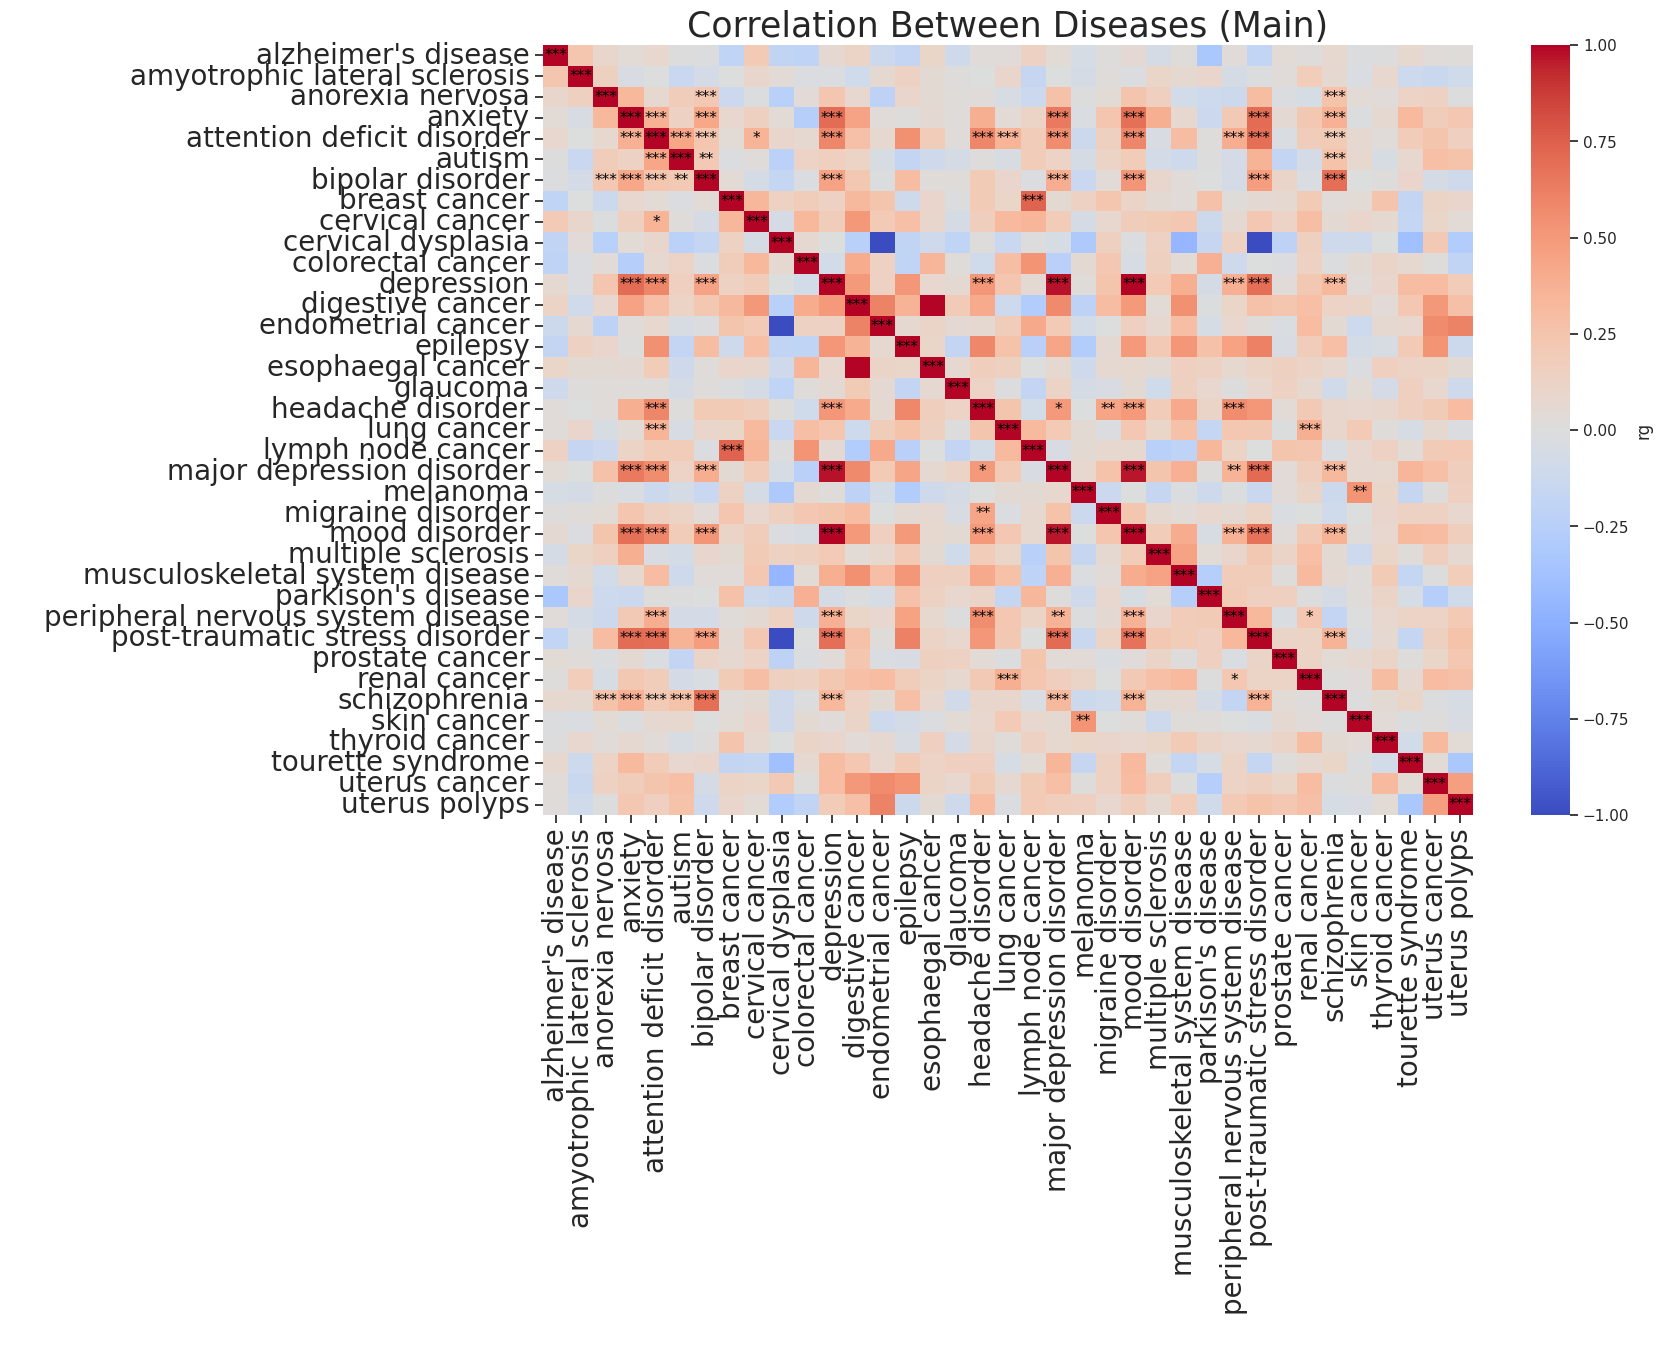

In [20]:
plot_heatmap(main_interest_heatmap, 'Correlation Between Diseases (Main)', " ", " ", "all_main_diseases")

/tmp/ipykernel_106800/1697512216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


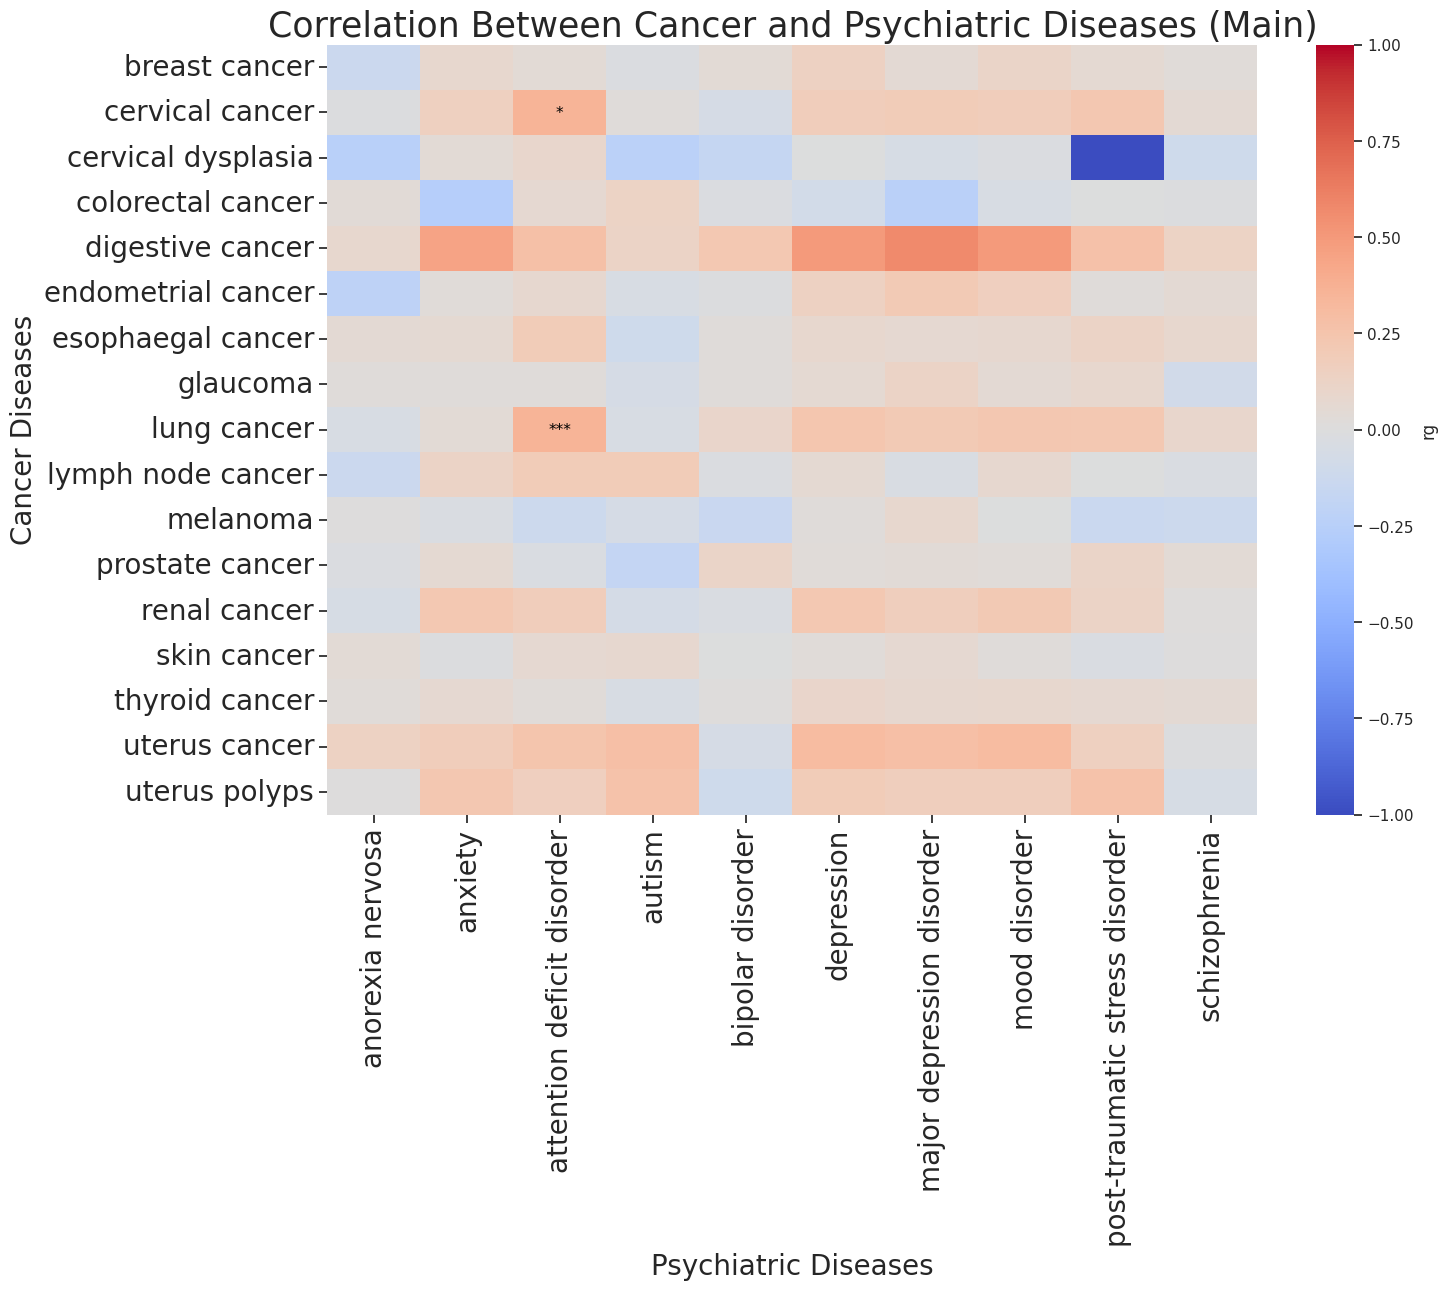

In [21]:
plot_heatmap(can_psy_interest_heatmap, 'Correlation Between Cancer and Psychiatric Diseases (Main)', "Psychiatric Diseases", "Cancer Diseases", "cancer_psy_main_diseases")

/tmp/ipykernel_106800/1697512216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


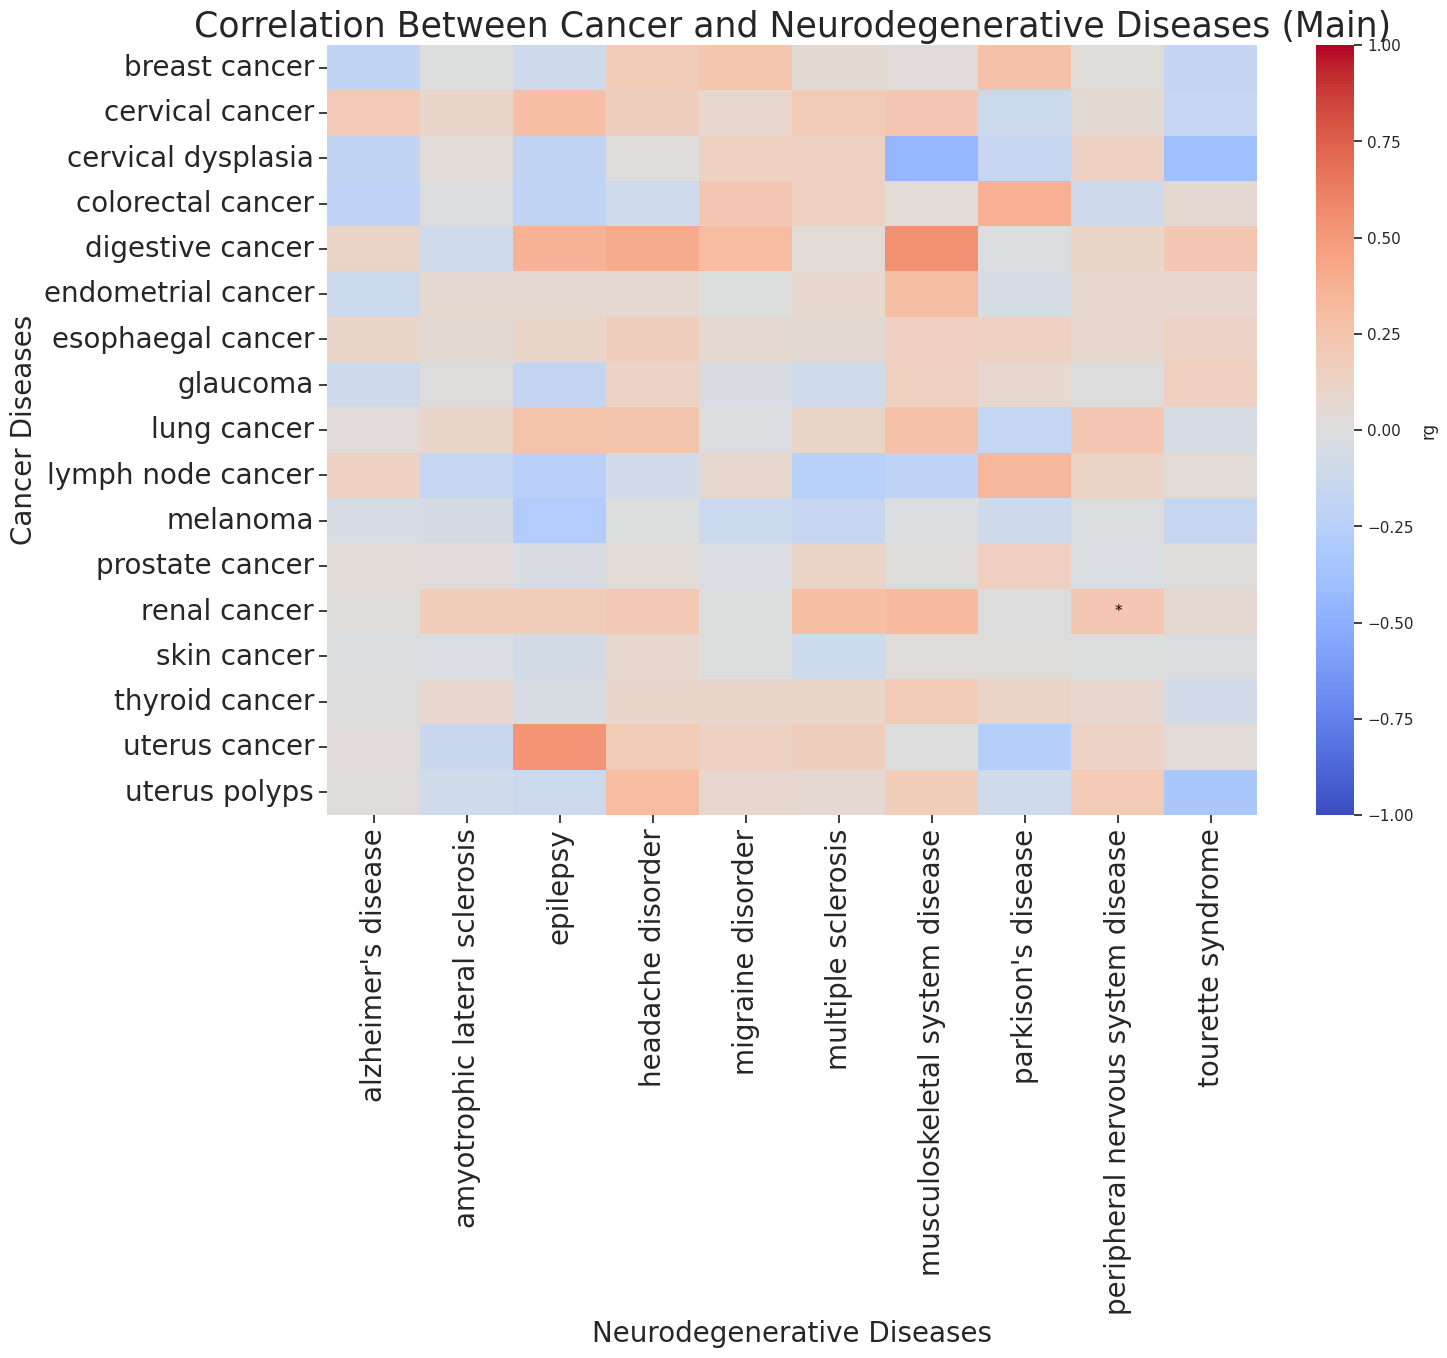

In [22]:
plot_heatmap(can_neu_interest_heatmap, 'Correlation Between Cancer and Neurodegenerative Diseases (Main)', "Neurodegenerative Diseases", "Cancer Diseases", "cancer_neu_main_diseases")

/tmp/ipykernel_106800/1697512216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


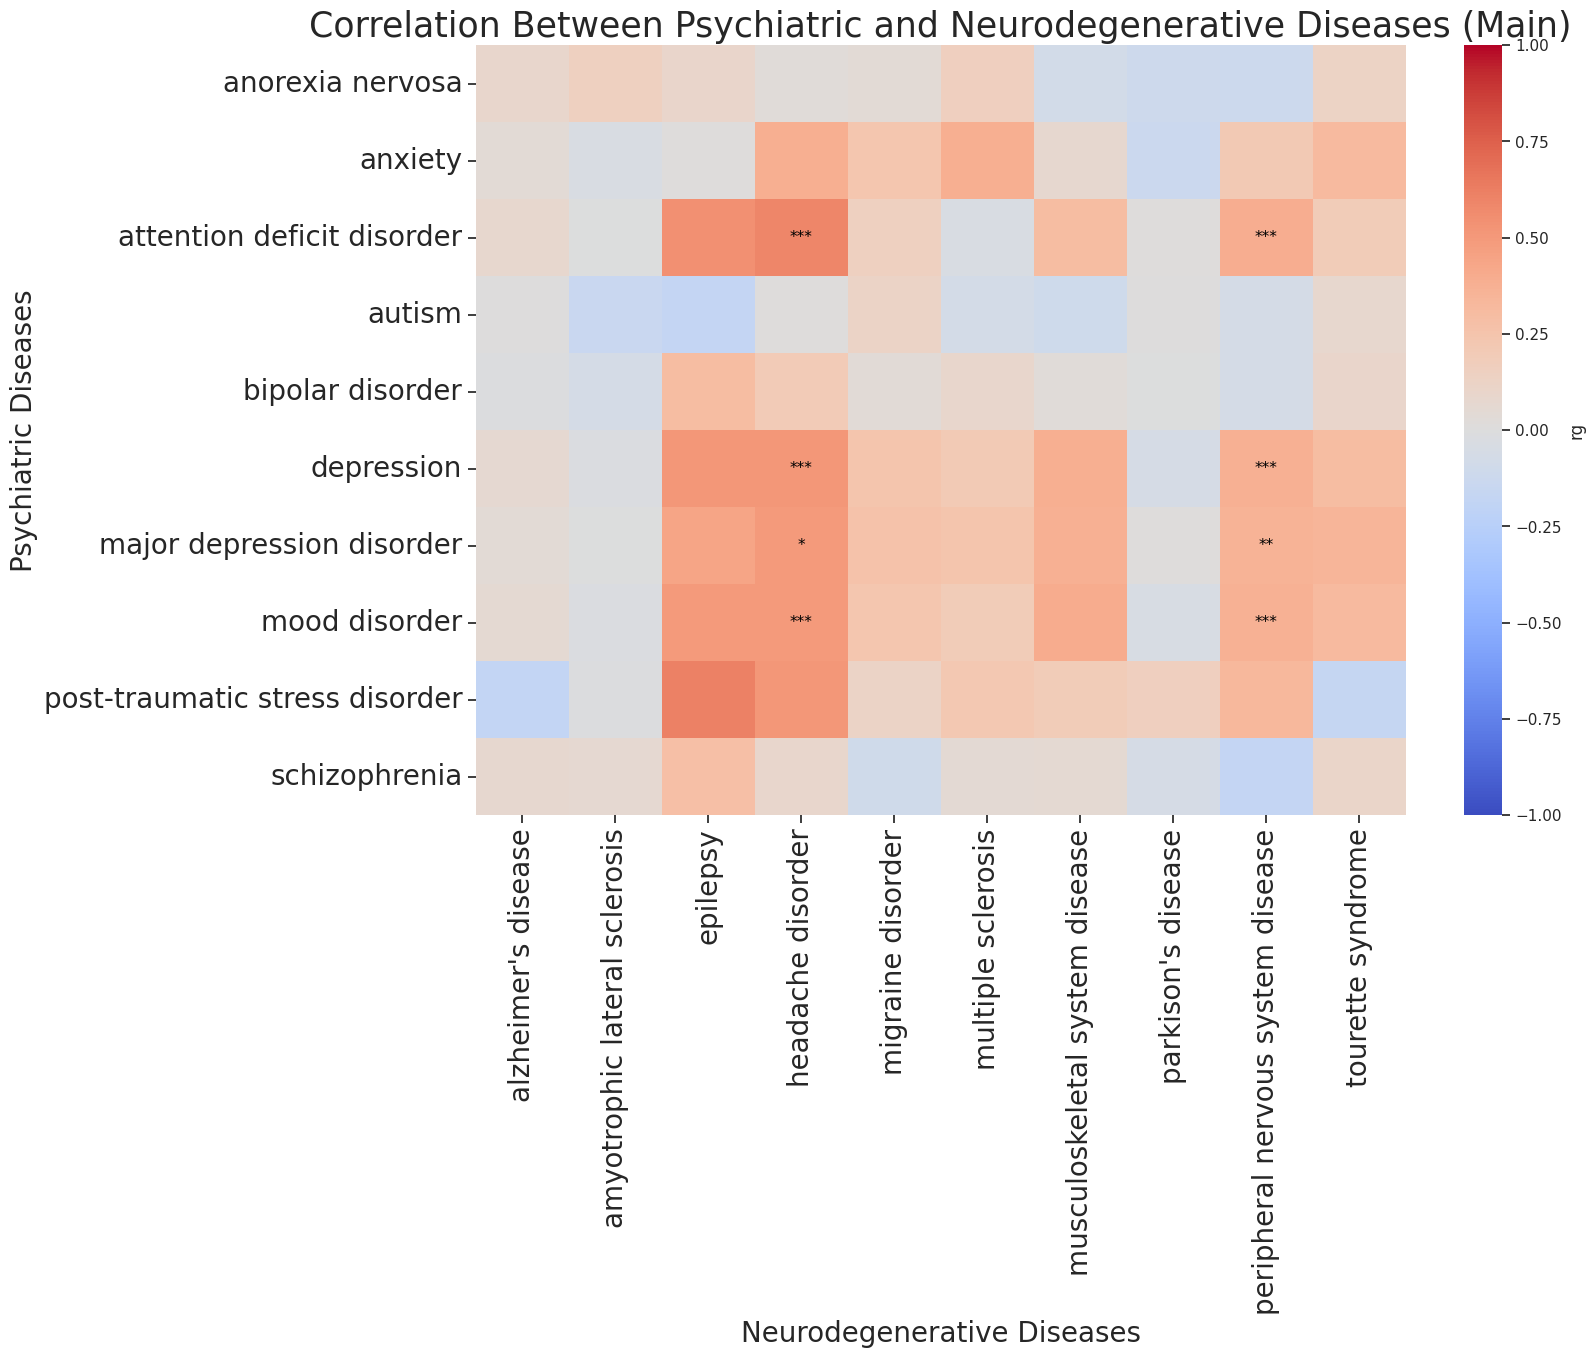

In [23]:
plot_heatmap(psy_neu_interest_heatmap, 'Correlation Between Psychiatric and Neurodegenerative Diseases (Main)', "Neurodegenerative Diseases", "Psychiatric Diseases", "neu_psy_main_diseases")

/tmp/ipykernel_106800/1697512216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


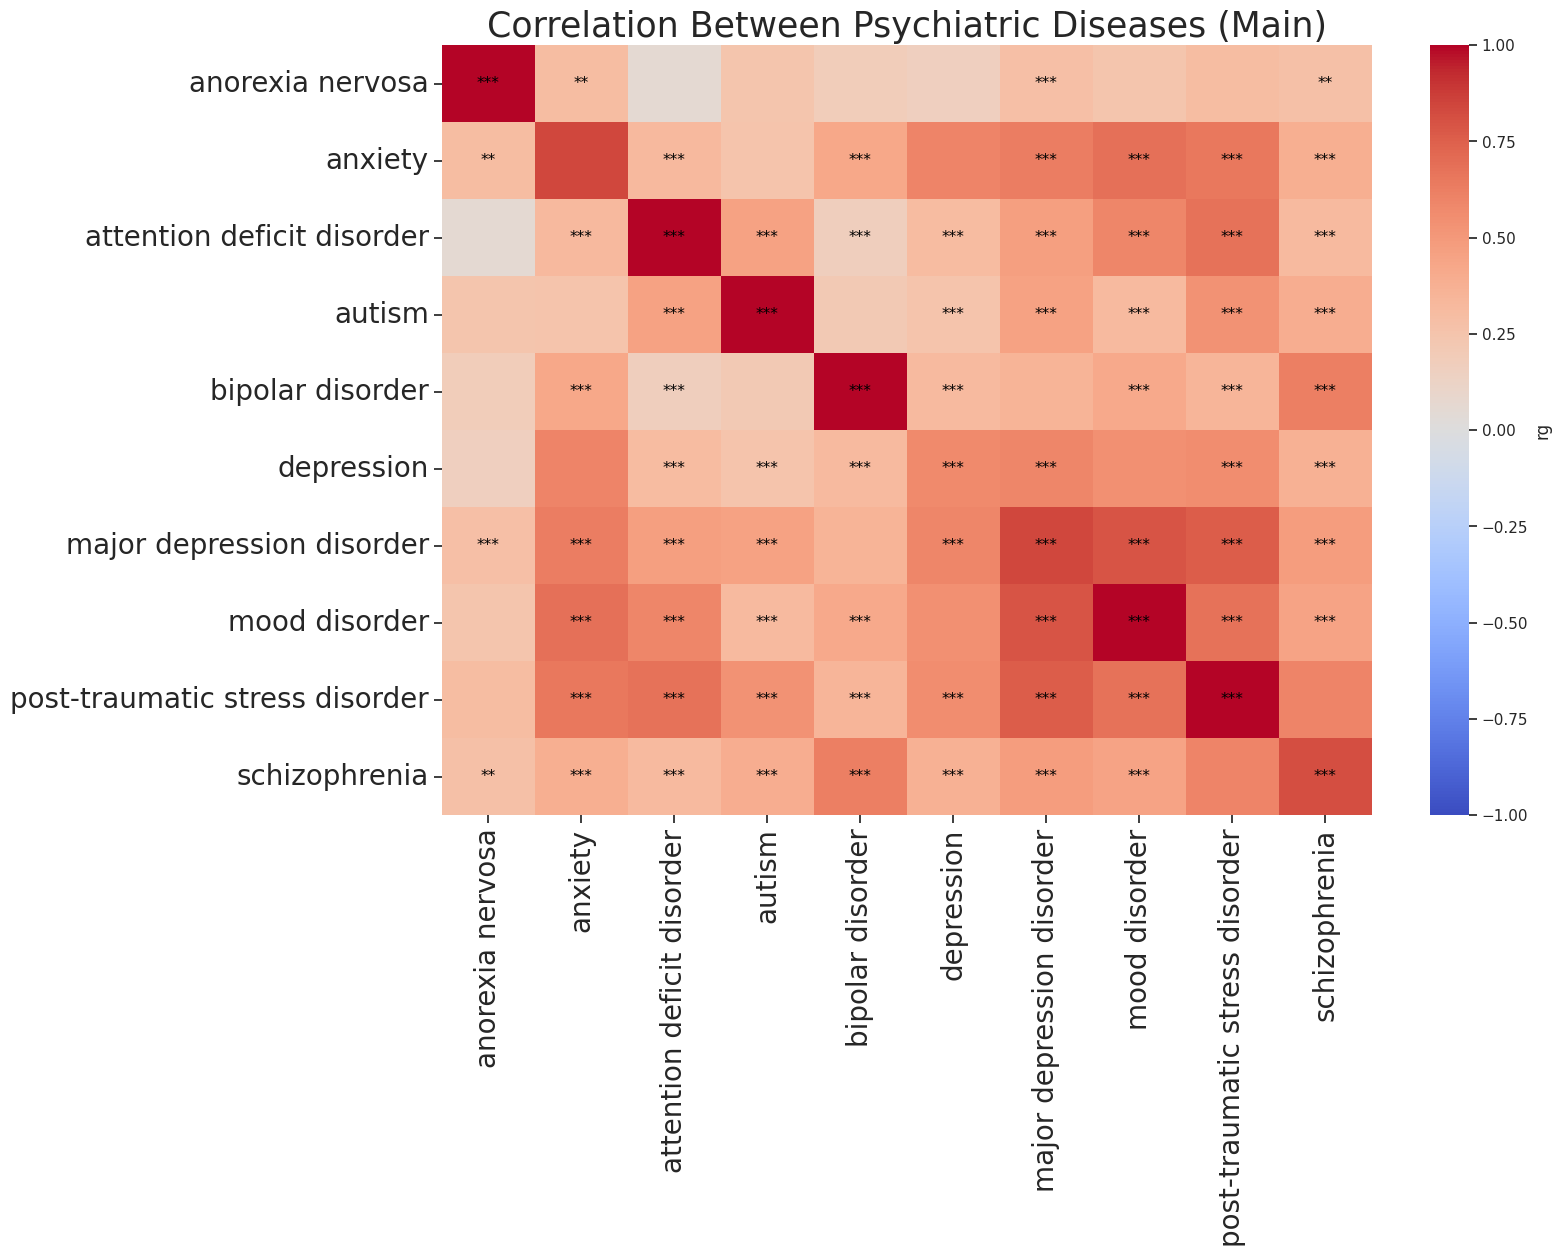

In [24]:
plot_heatmap(psy_psy_all_heatmap, 'Correlation Between Psychiatric Diseases (Main)', "", "",  "psy_psy_main_diseases")

/tmp/ipykernel_106800/1697512216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


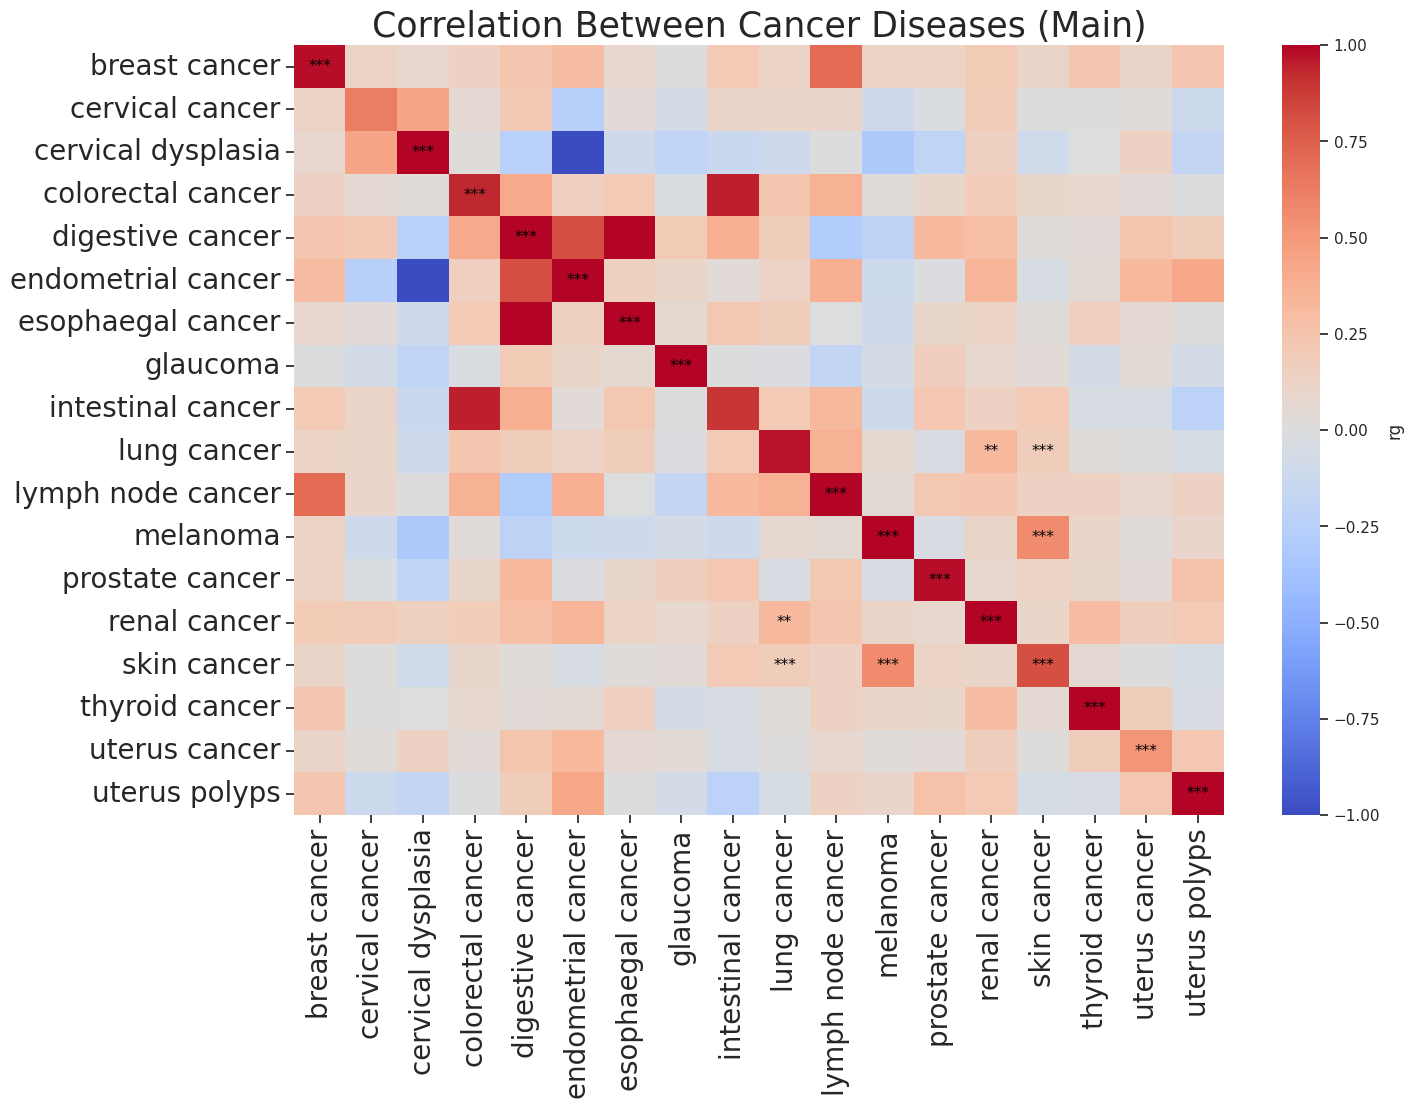

In [25]:
plot_heatmap(can_can_all_heatmap, 'Correlation Between Cancer Diseases (Main)', "", "", "cancer_cancer_main_diseases")

/tmp/ipykernel_106800/1697512216.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


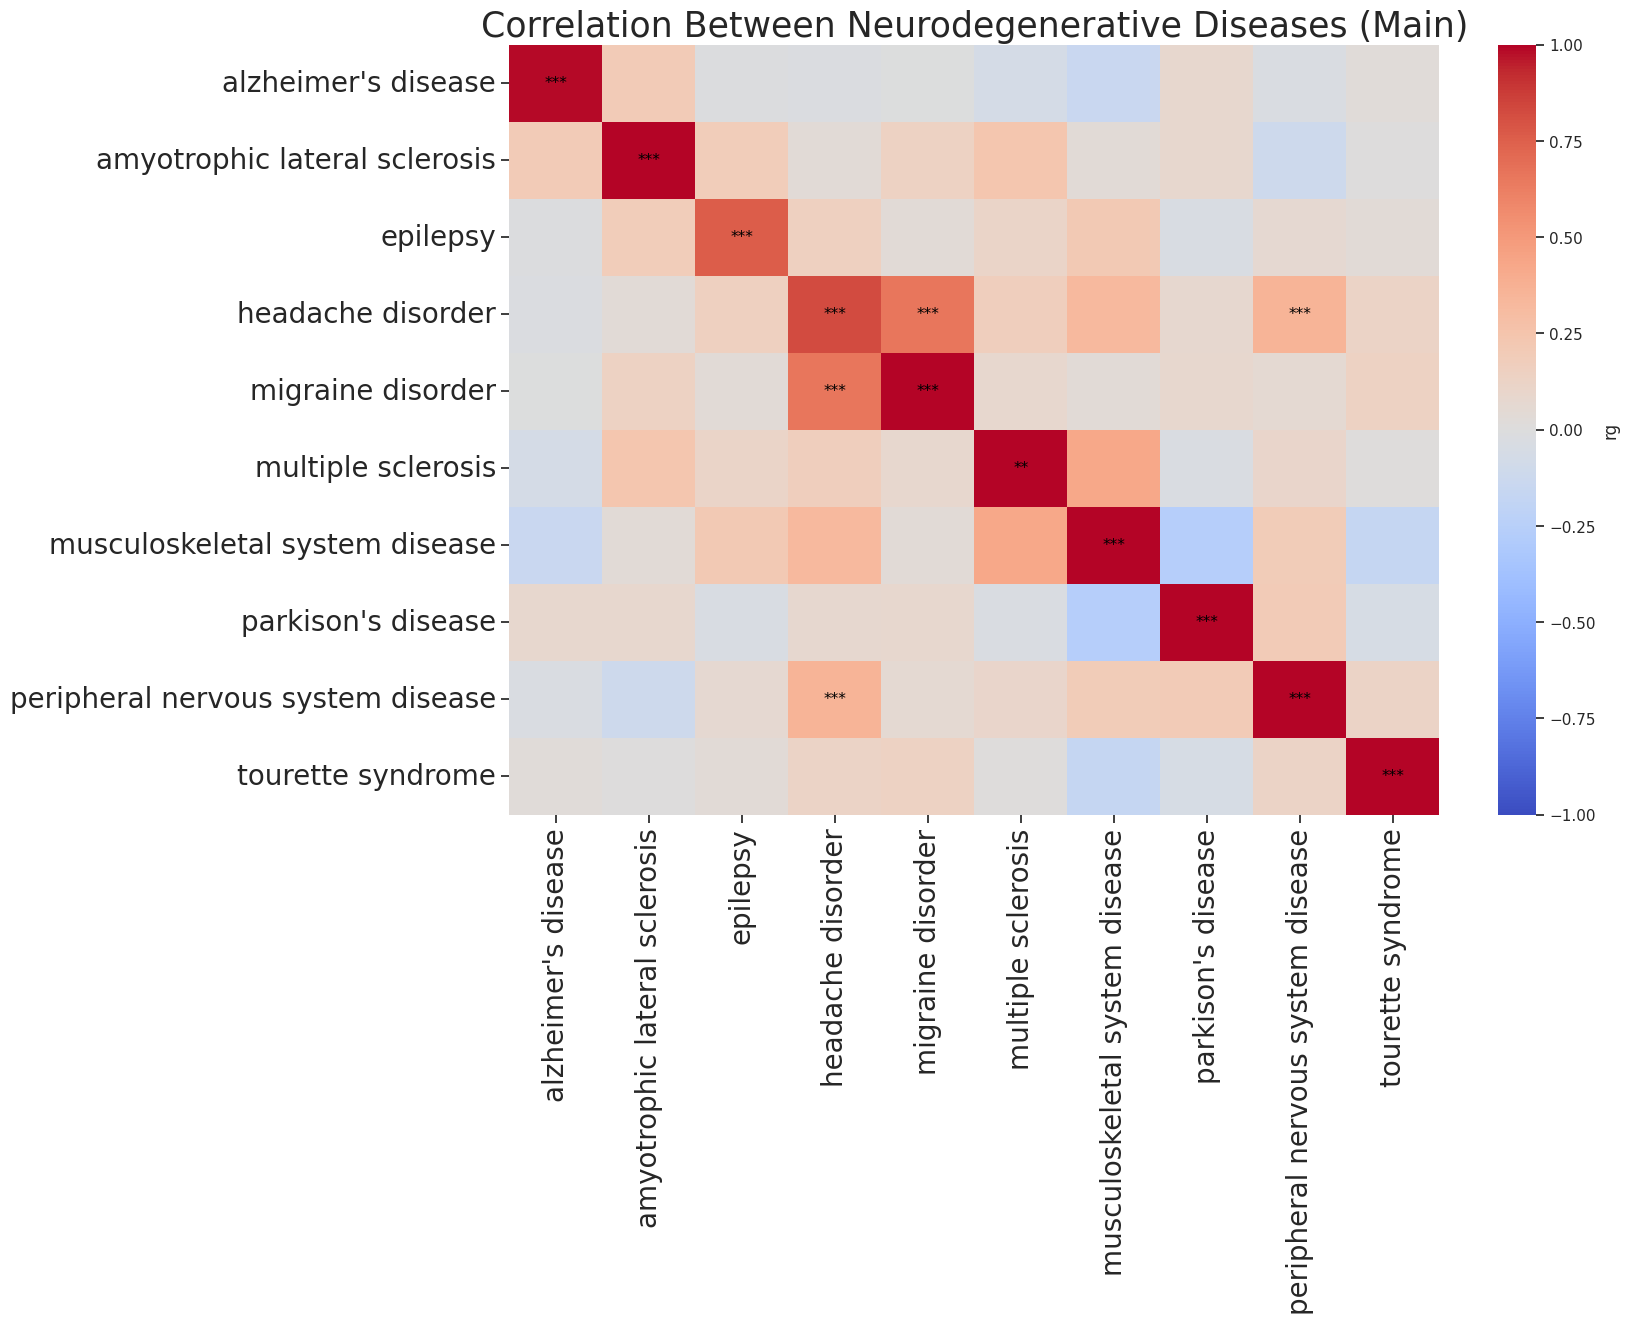

In [26]:
plot_heatmap(neu_neu_all_heatmap, 'Correlation Between Neurodegenerative Diseases (Main)', "", "",  "neu_neu_main_diseases")

### All categories heatmaps

In [28]:
def plot_heatmap_all(df, title, xlabel, ylabel, name_figure):
    # Calculate Significance Levels
    df['significance'] = pd.cut(
        df['p_corrected'],
        bins=[-np.inf, 0.001, 0.01, 0.05, np.inf],
        labels=["***", "**", "*", ""]
    )

    # Pivot for heatmap
    heatmap_data = df.pivot_table(
        index="label_1", columns="label_2", values="rg", aggfunc="mean"
    )
    significance_data = df.pivot_table(
        index="label_1", columns="label_2", values="significance", aggfunc="first"
    )

    # mask = np.triu(np.ones_like(heatmap_data, dtype=bool))

    # Plot Heatmap
    plt.figure(figsize=(20, 15))
    # sns.set(style="ticks")
    ax = sns.heatmap(heatmap_data, annot=significance_data, fmt="", cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={'label': 'rg'}, annot_kws={"color": "black", "size":8})
    # Customize plot appearance
    ax.set_title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(fontsize=12) 
    plt.yticks(fontsize=12) 
    
    # Save
    plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/{name_figure}_LDSC.png", bbox_inches="tight")
    plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/{name_figure}_LDSC.jpg", bbox_inches="tight")
    plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/{name_figure}_LDSC.pdf", bbox_inches="tight")
    
    plt.show()

In [29]:
minor_interest_heatmap = full_ldsc[(full_ldsc["selection_1"] == "minor") & (full_ldsc["selection_2"] == "minor")]

# For CAN and PSY
can_psy_all_heatmap = full_ldsc[(full_ldsc["type_1"] == "CAN") & (full_ldsc["type_2"] == "PSY")]
# can_psy_all_heatmap = can_psy_all_heatmap[(can_psy_all_heatmap["selection_1"] == "minor") & (can_psy_all_heatmap["selection_2"] == "minor")]
# For CAN and NEU
can_neu_all_heatmap = full_ldsc[(full_ldsc["type_1"] == "CAN") & (full_ldsc["type_2"] == "NEU")]
# can_neu_all_heatmap = can_neu_all_heatmap[(can_neu_all_heatmap["selection_1"] == "minor") & (can_neu_all_heatmap["selection_2"] == "minor")]

# For PSY and NEU
psy_neu_all_heatmap = full_ldsc[(full_ldsc["type_1"] == "PSY") & (full_ldsc["type_2"] == "NEU")]
# psy_neu_all_heatmap = psy_neu_all_heatmap[(psy_neu_all_heatmap["selection_1"] == "minor") & (psy_neu_all_heatmap["selection_2"] == "minor")]



/tmp/ipykernel_106800/515110427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


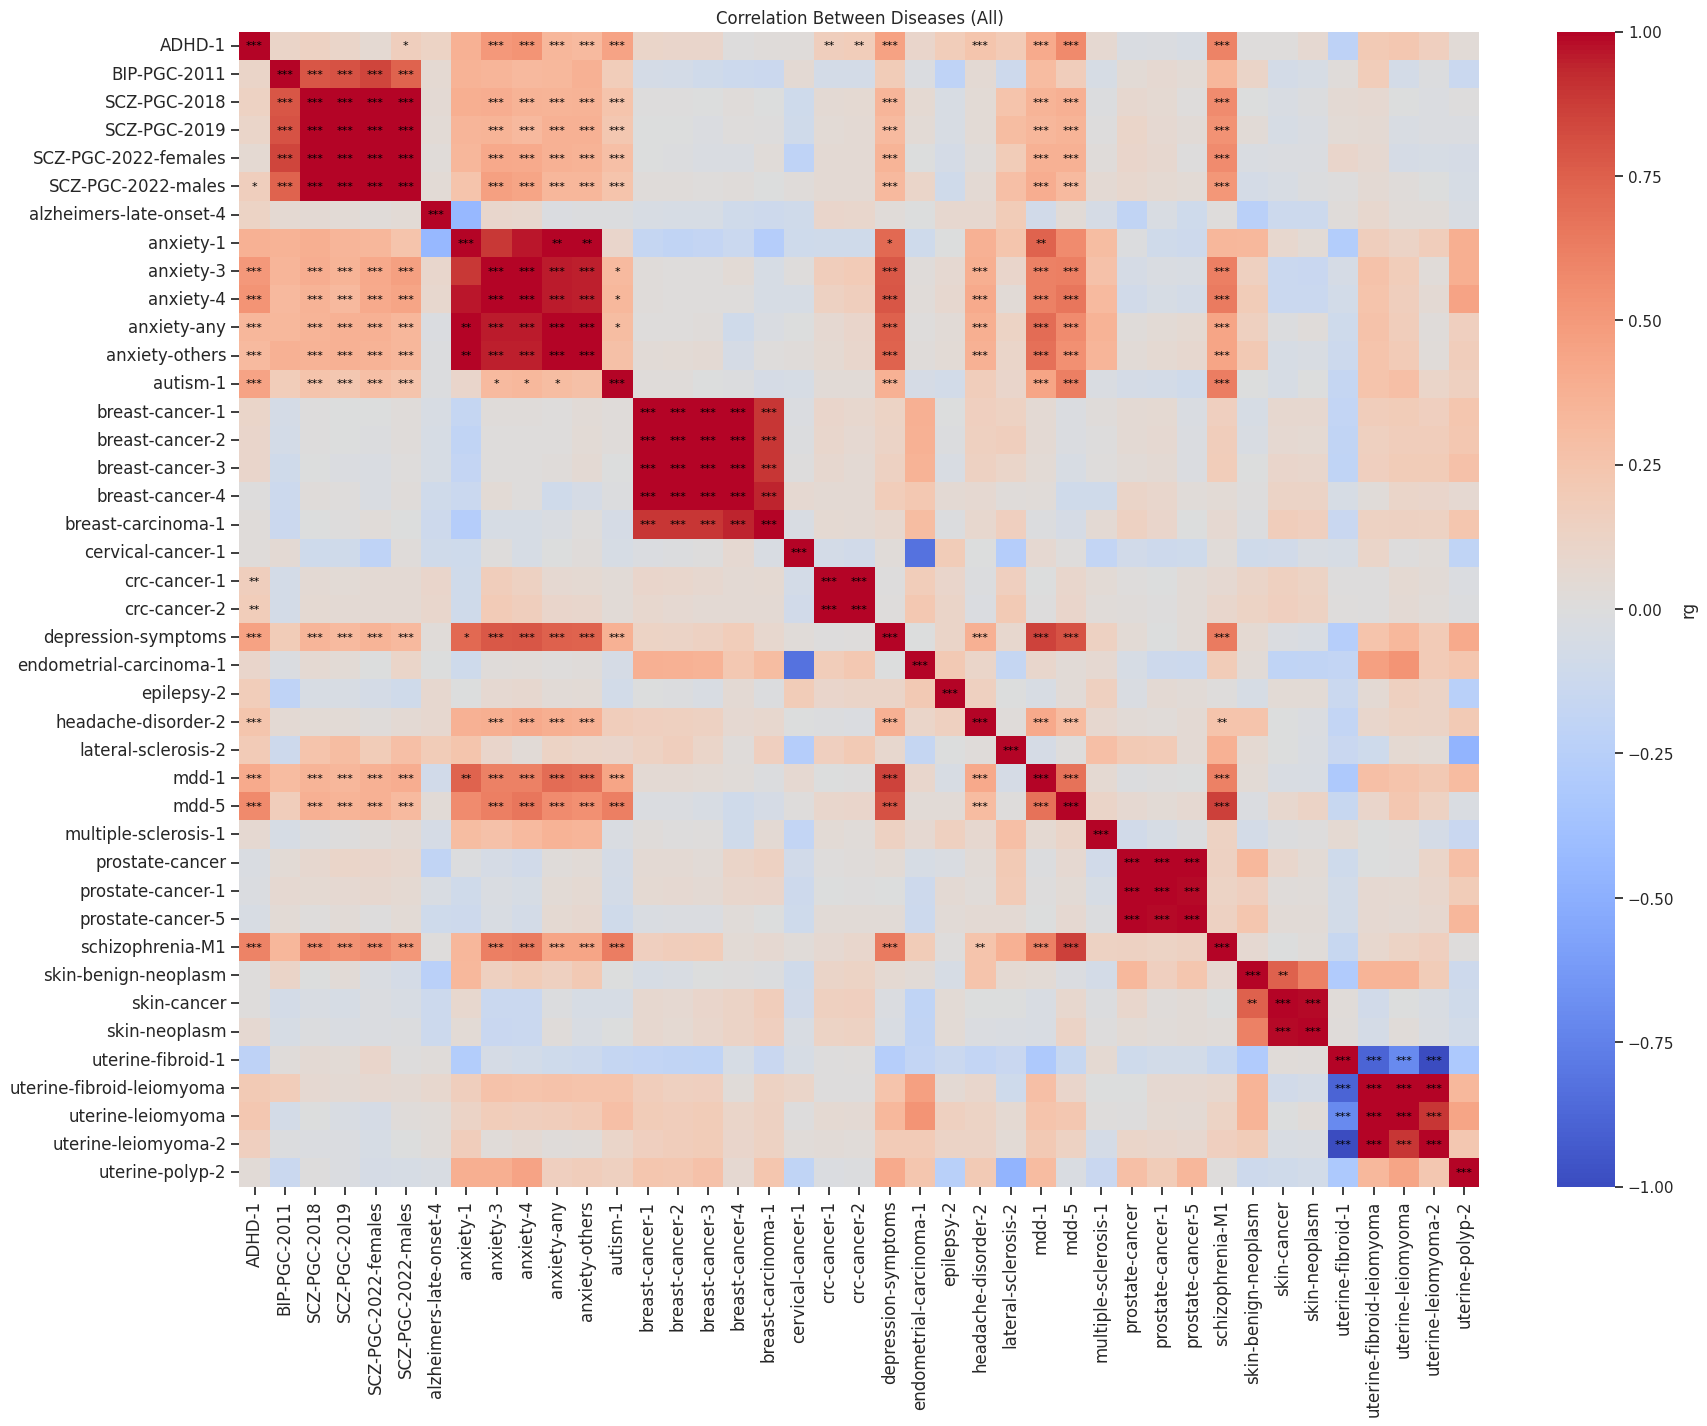

In [30]:
plot_heatmap_all(minor_interest_heatmap, 'Correlation Between Diseases (All)', "", "", "minor_all_diseases")

/tmp/ipykernel_106800/515110427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


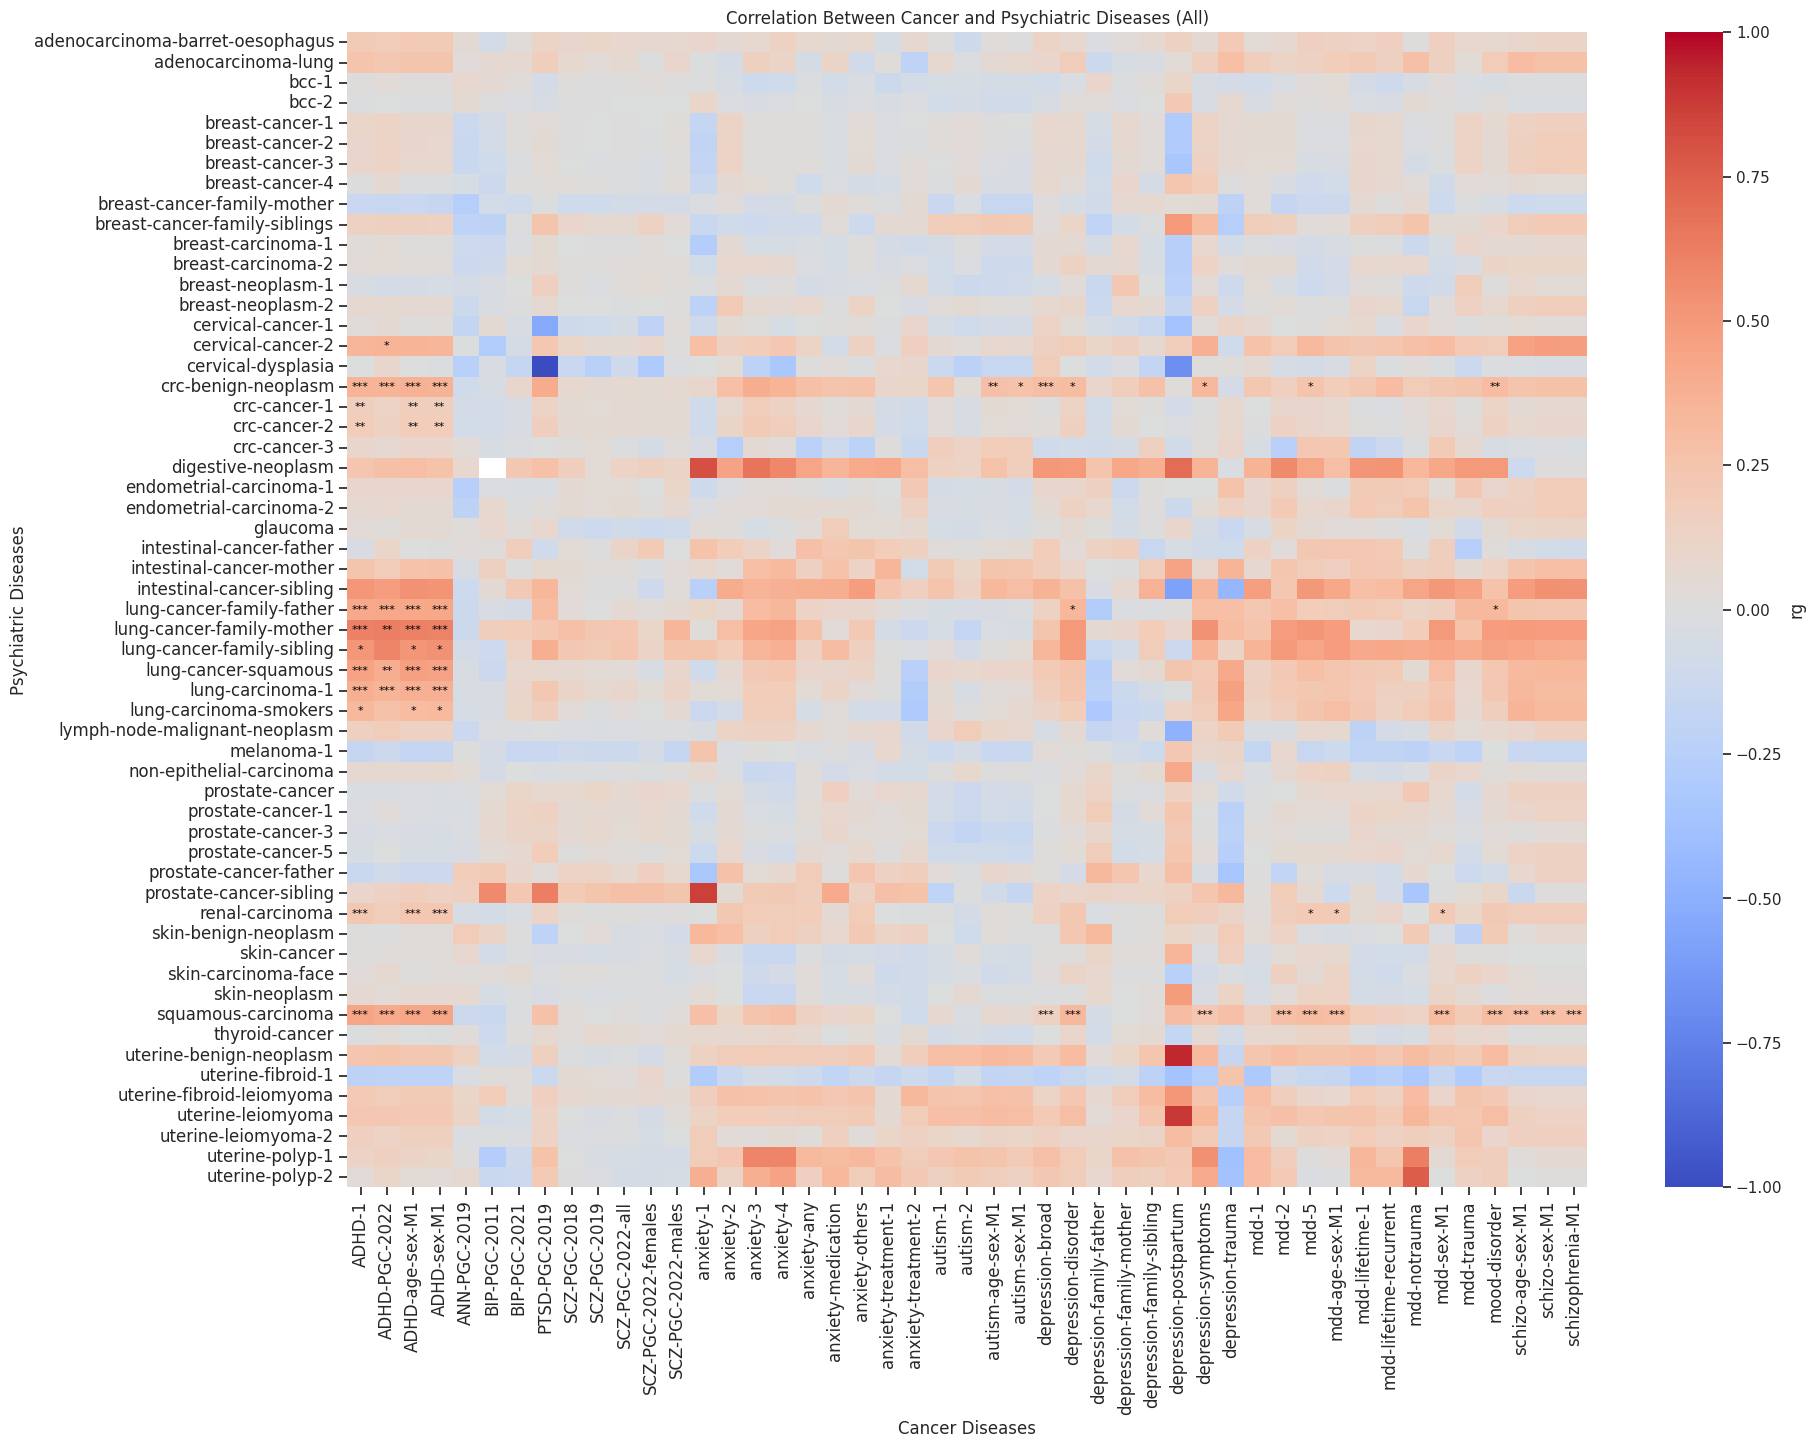

In [31]:
plot_heatmap_all(can_psy_all_heatmap, 'Correlation Between Cancer and Psychiatric Diseases (All)', "Cancer Diseases", "Psychiatric Diseases", "cancer_psy_all_diseases")

/tmp/ipykernel_106800/515110427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


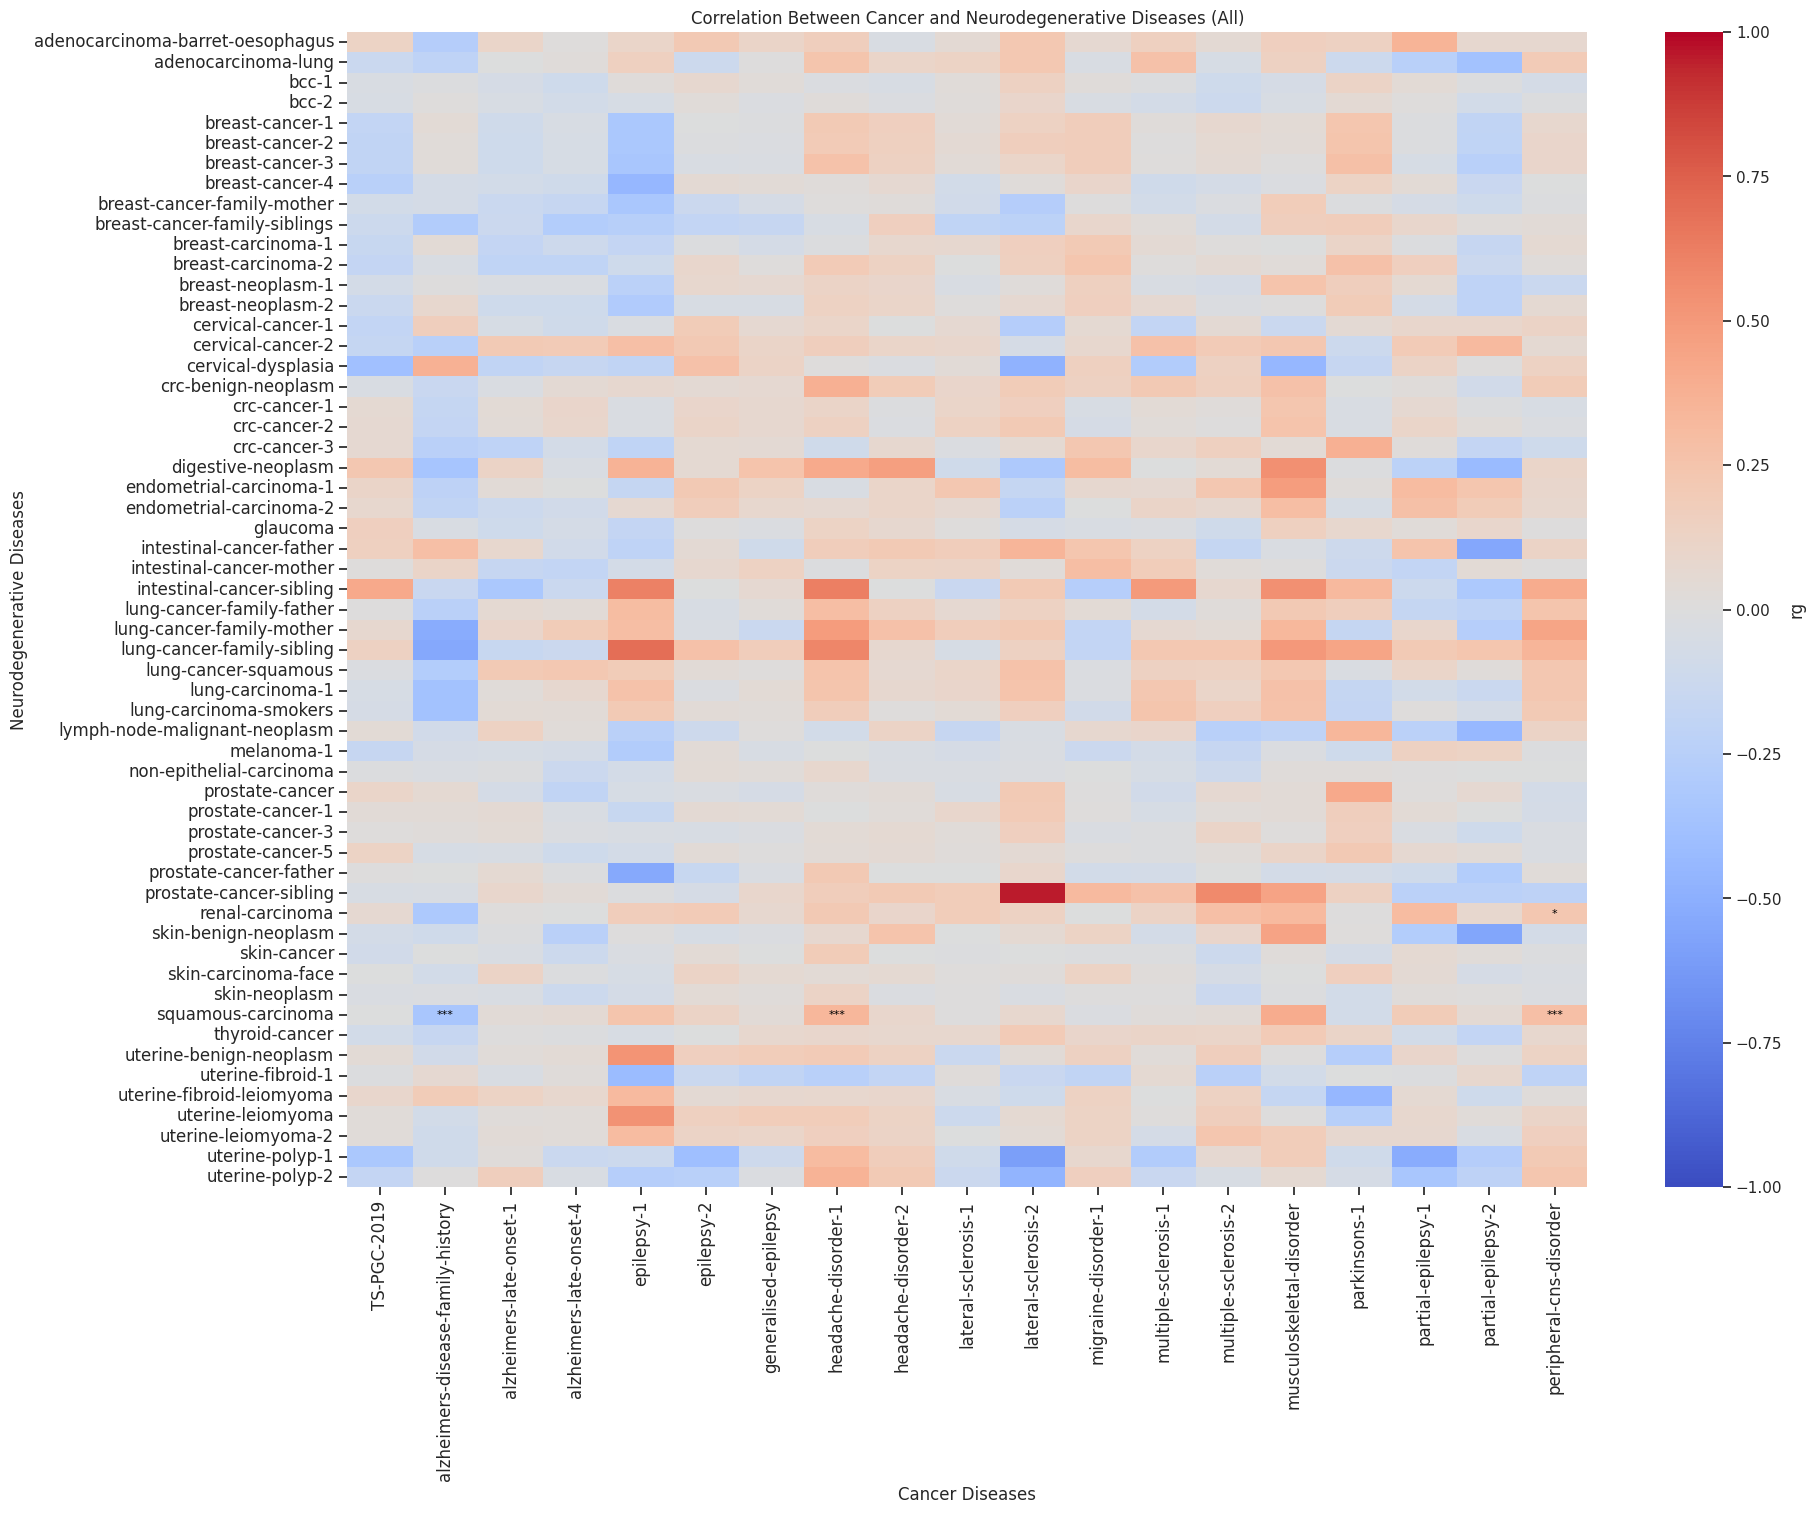

In [32]:
plot_heatmap_all(can_neu_all_heatmap, 'Correlation Between Cancer and Neurodegenerative Diseases (All)', "Cancer Diseases", "Neurodegenerative Diseases", "cancer_psy_all_diseases")

/tmp/ipykernel_106800/515110427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


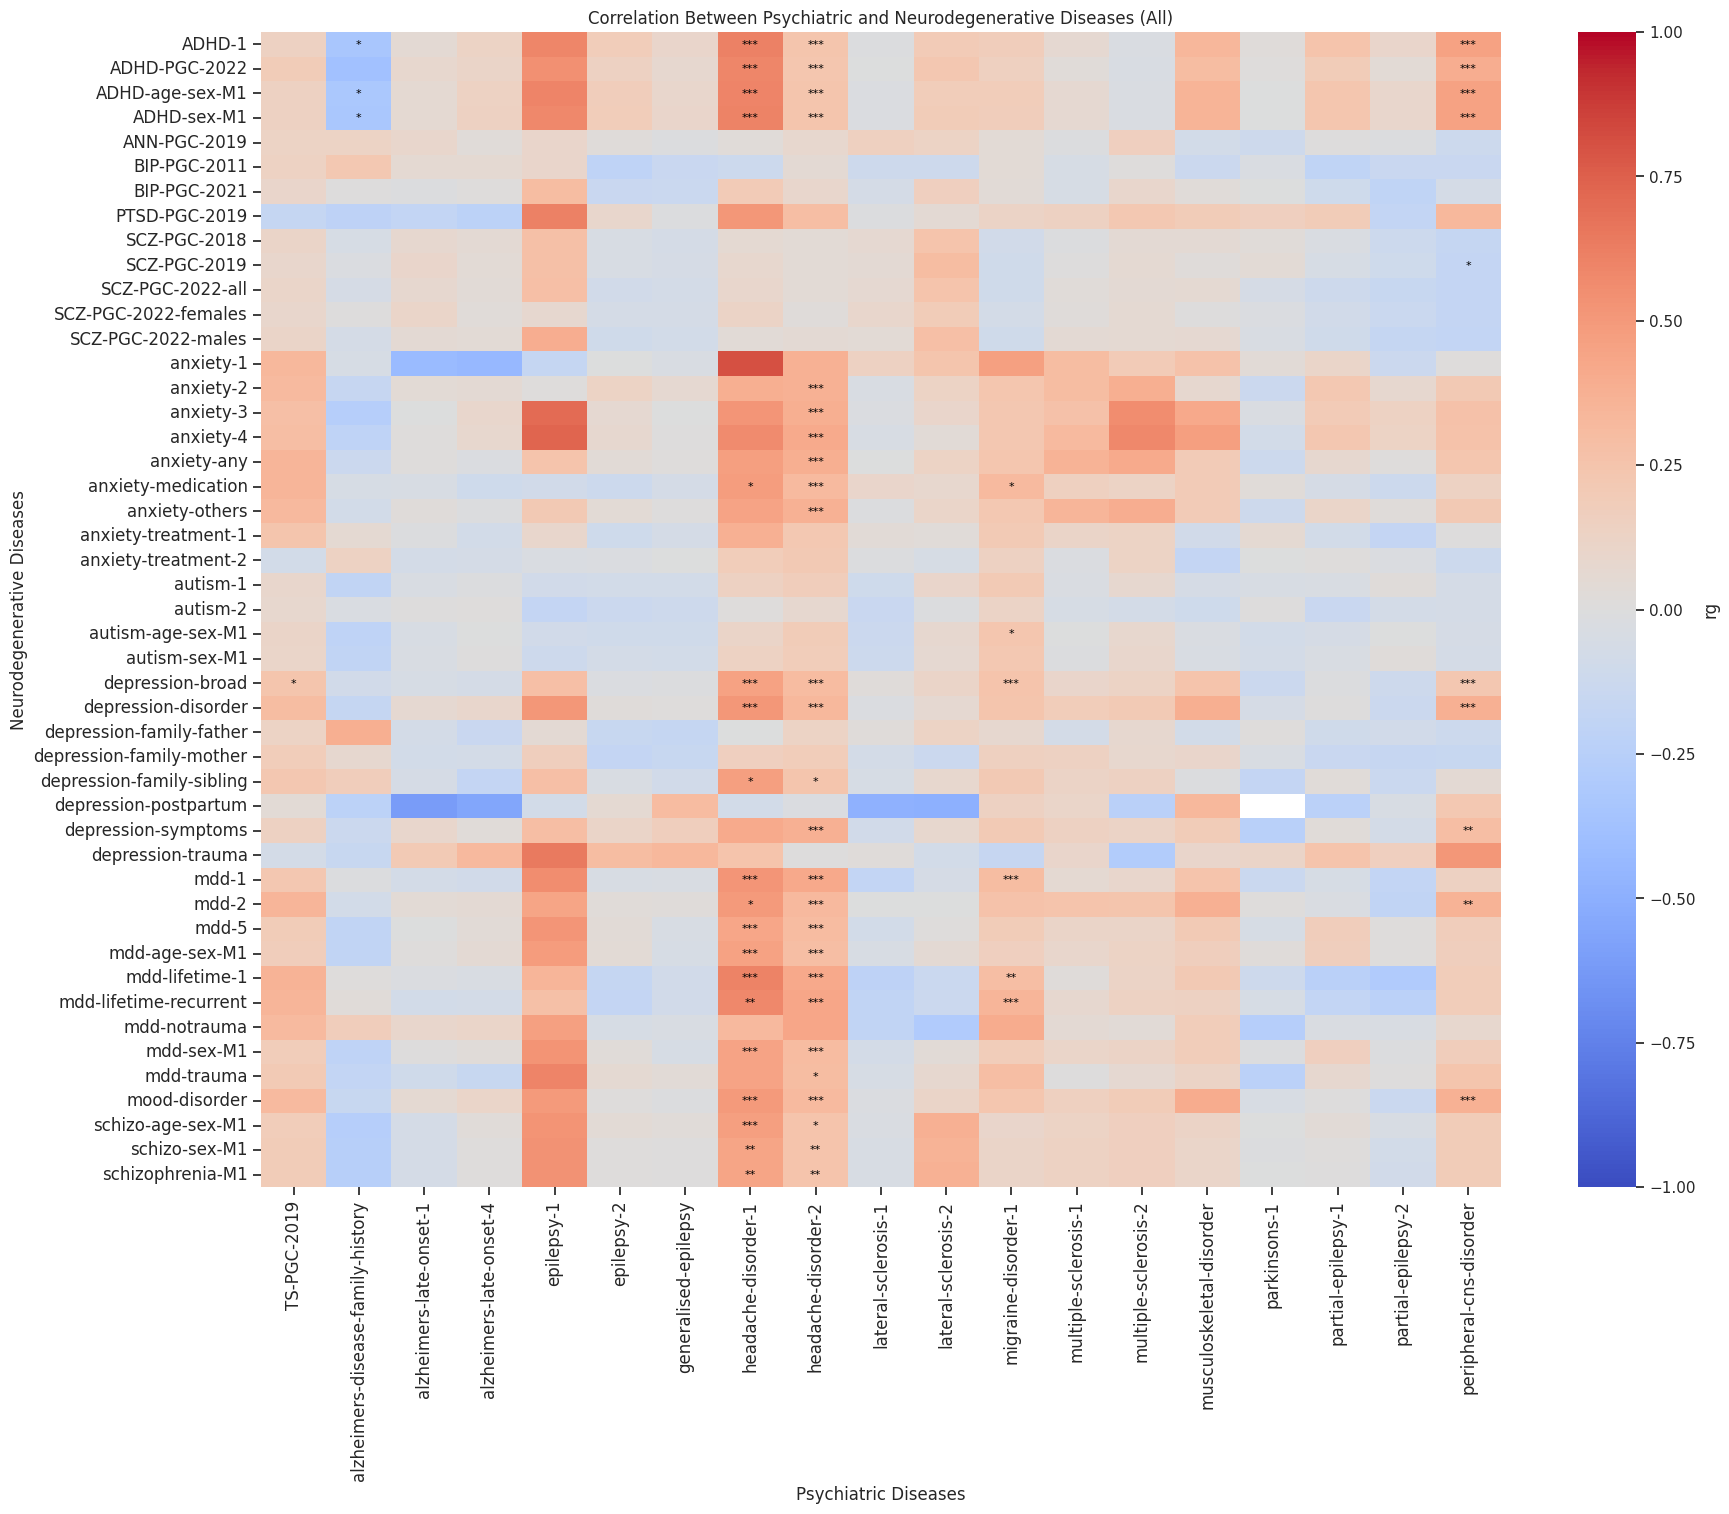

In [33]:
plot_heatmap_all(psy_neu_all_heatmap, 'Correlation Between Psychiatric and Neurodegenerative Diseases (All)', "Psychiatric Diseases", "Neurodegenerative Diseases", "neu_psy_all_diseases")

/tmp/ipykernel_106800/515110427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


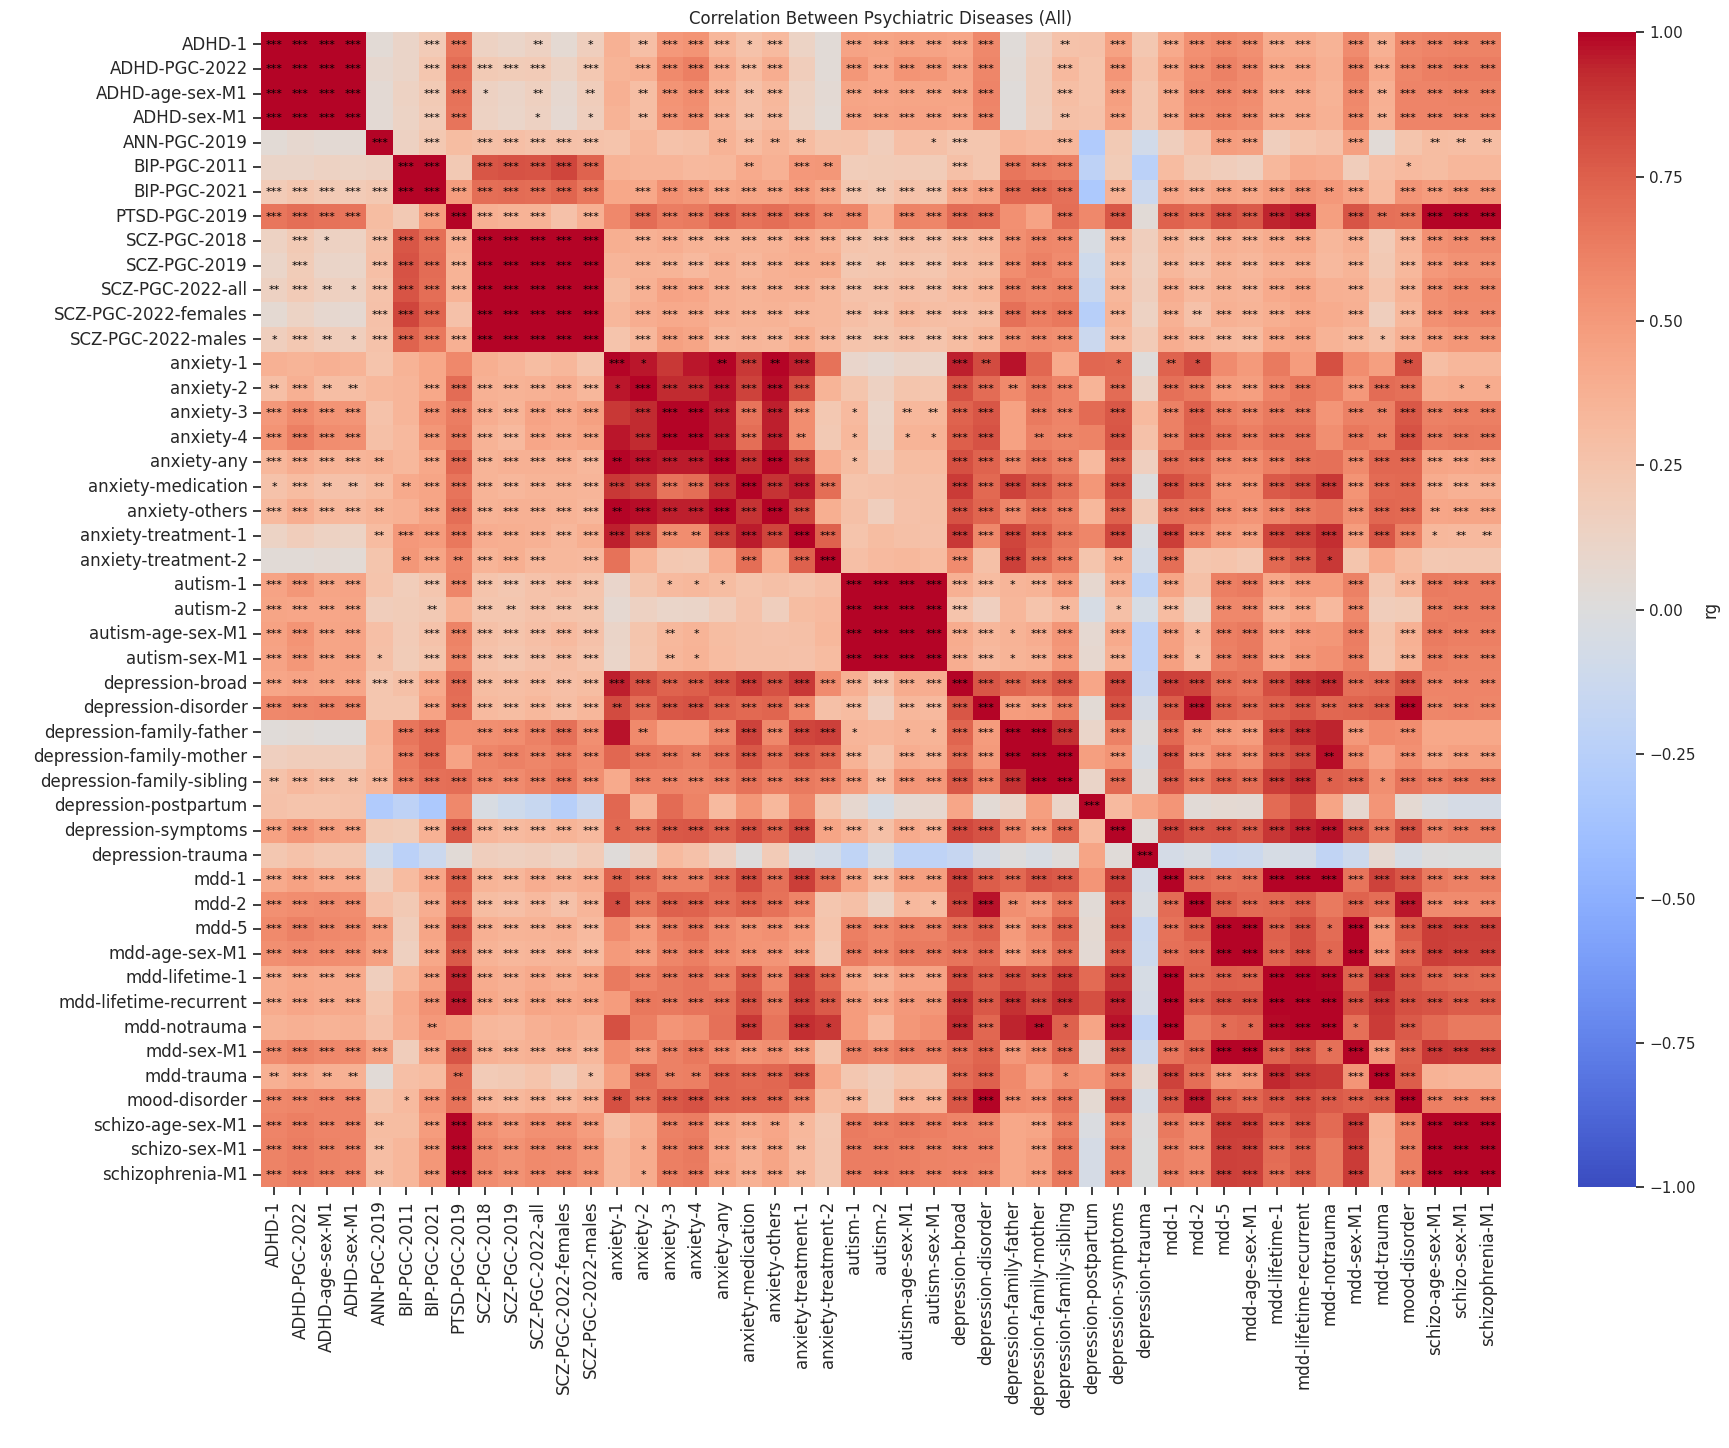

In [34]:
plot_heatmap_all(psy_psy_all_heatmap, 'Correlation Between Psychiatric Diseases (All)', " ", " ", "psy_psy_all_diseases")

/tmp/ipykernel_106800/515110427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


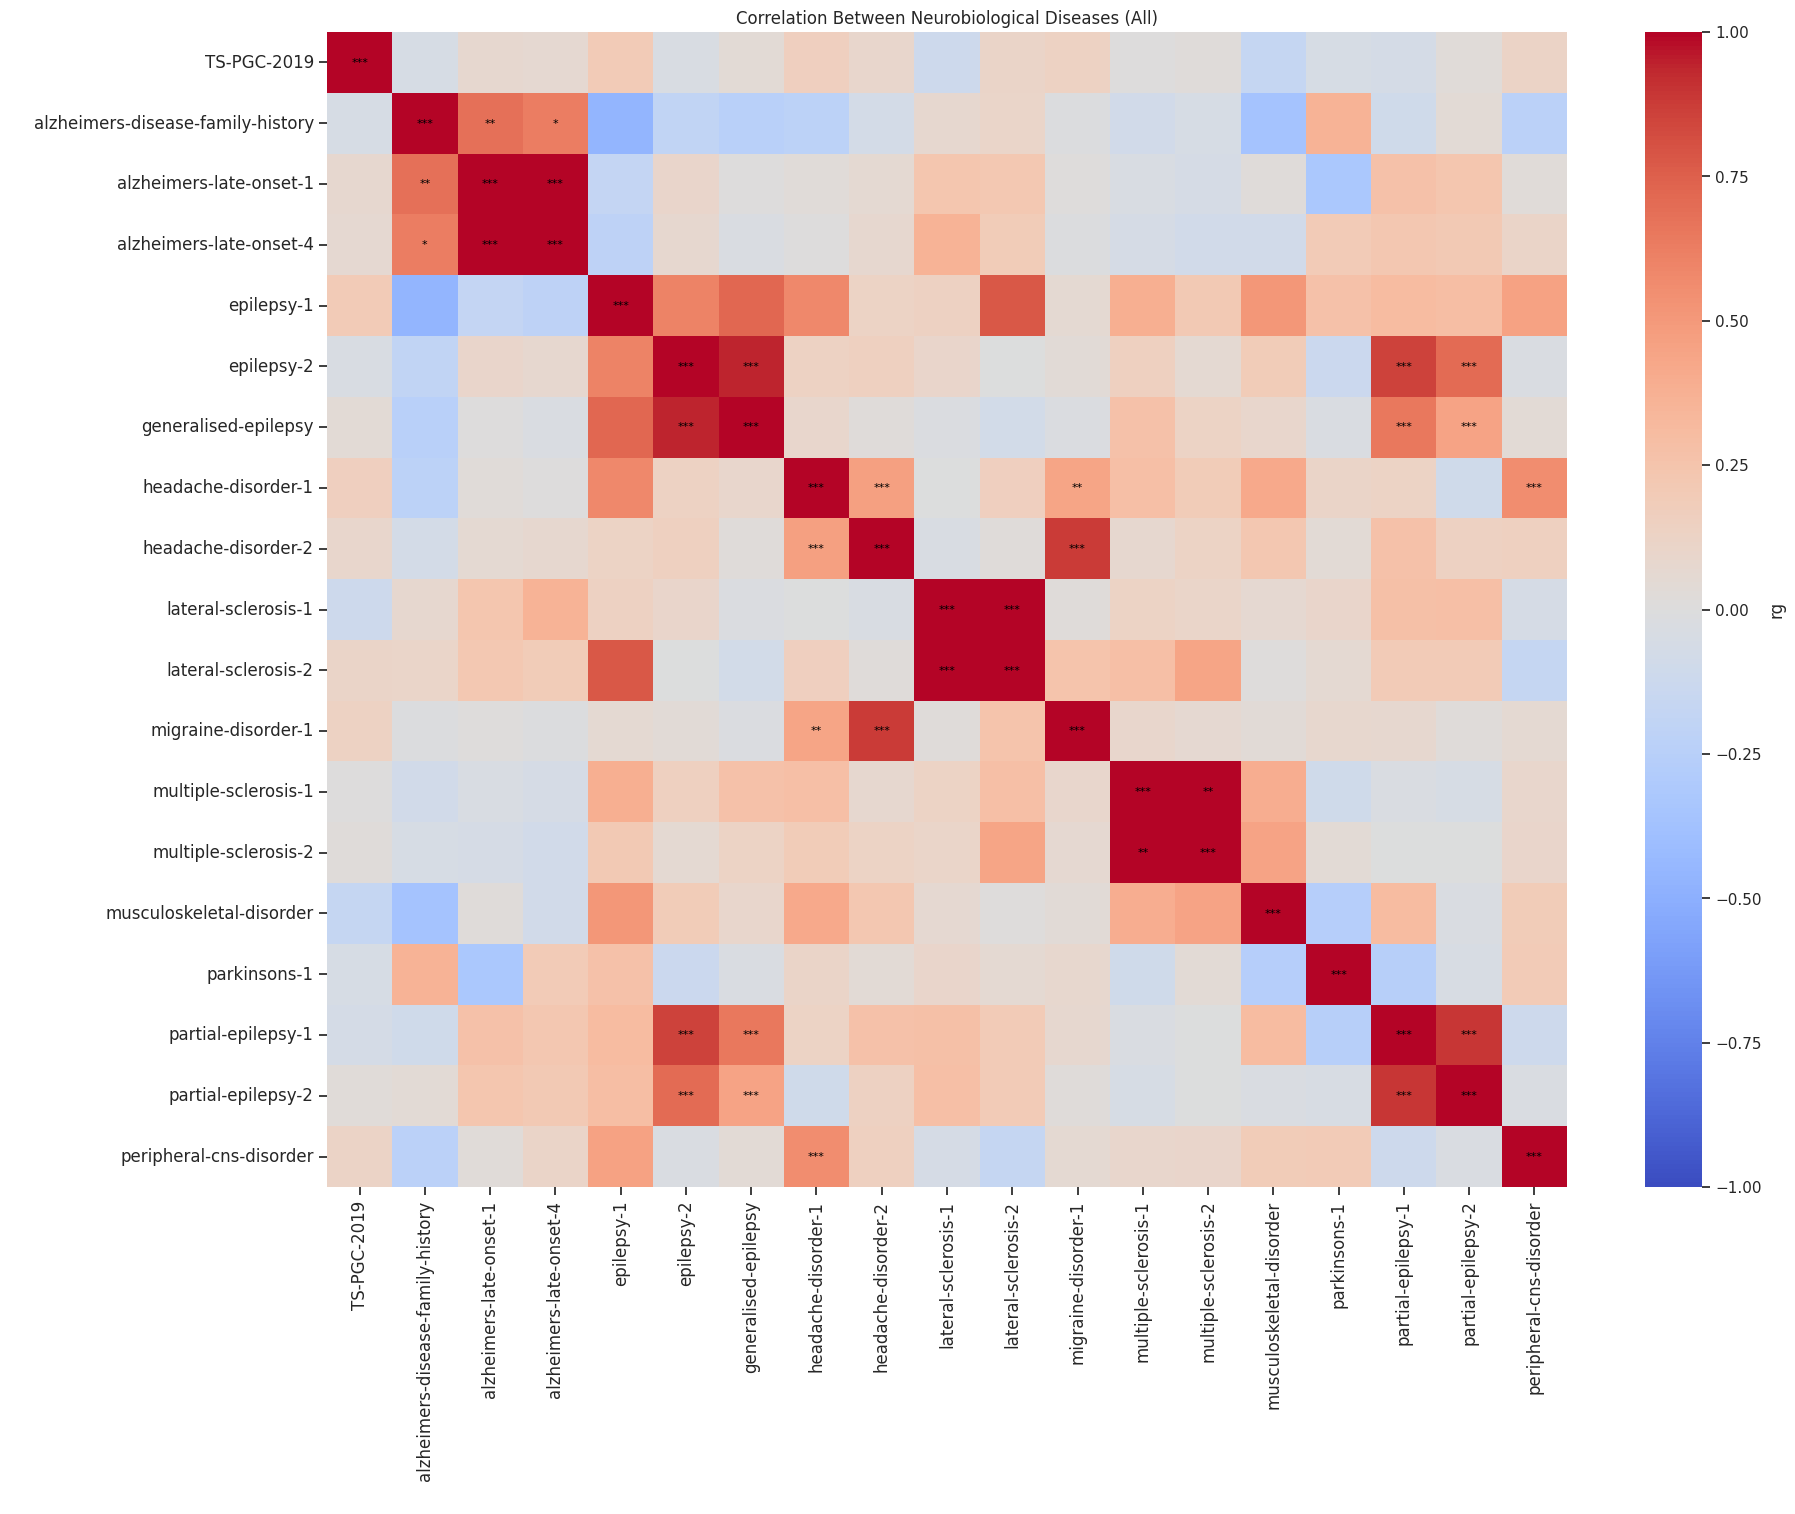

In [36]:
plot_heatmap_all(neu_neu_all_heatmap, 'Correlation Between Neurobiological Diseases (All)', " ", " ", "neu_neu_all_diseases")

/tmp/ipykernel_106800/515110427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['significance'] = pd.cut(


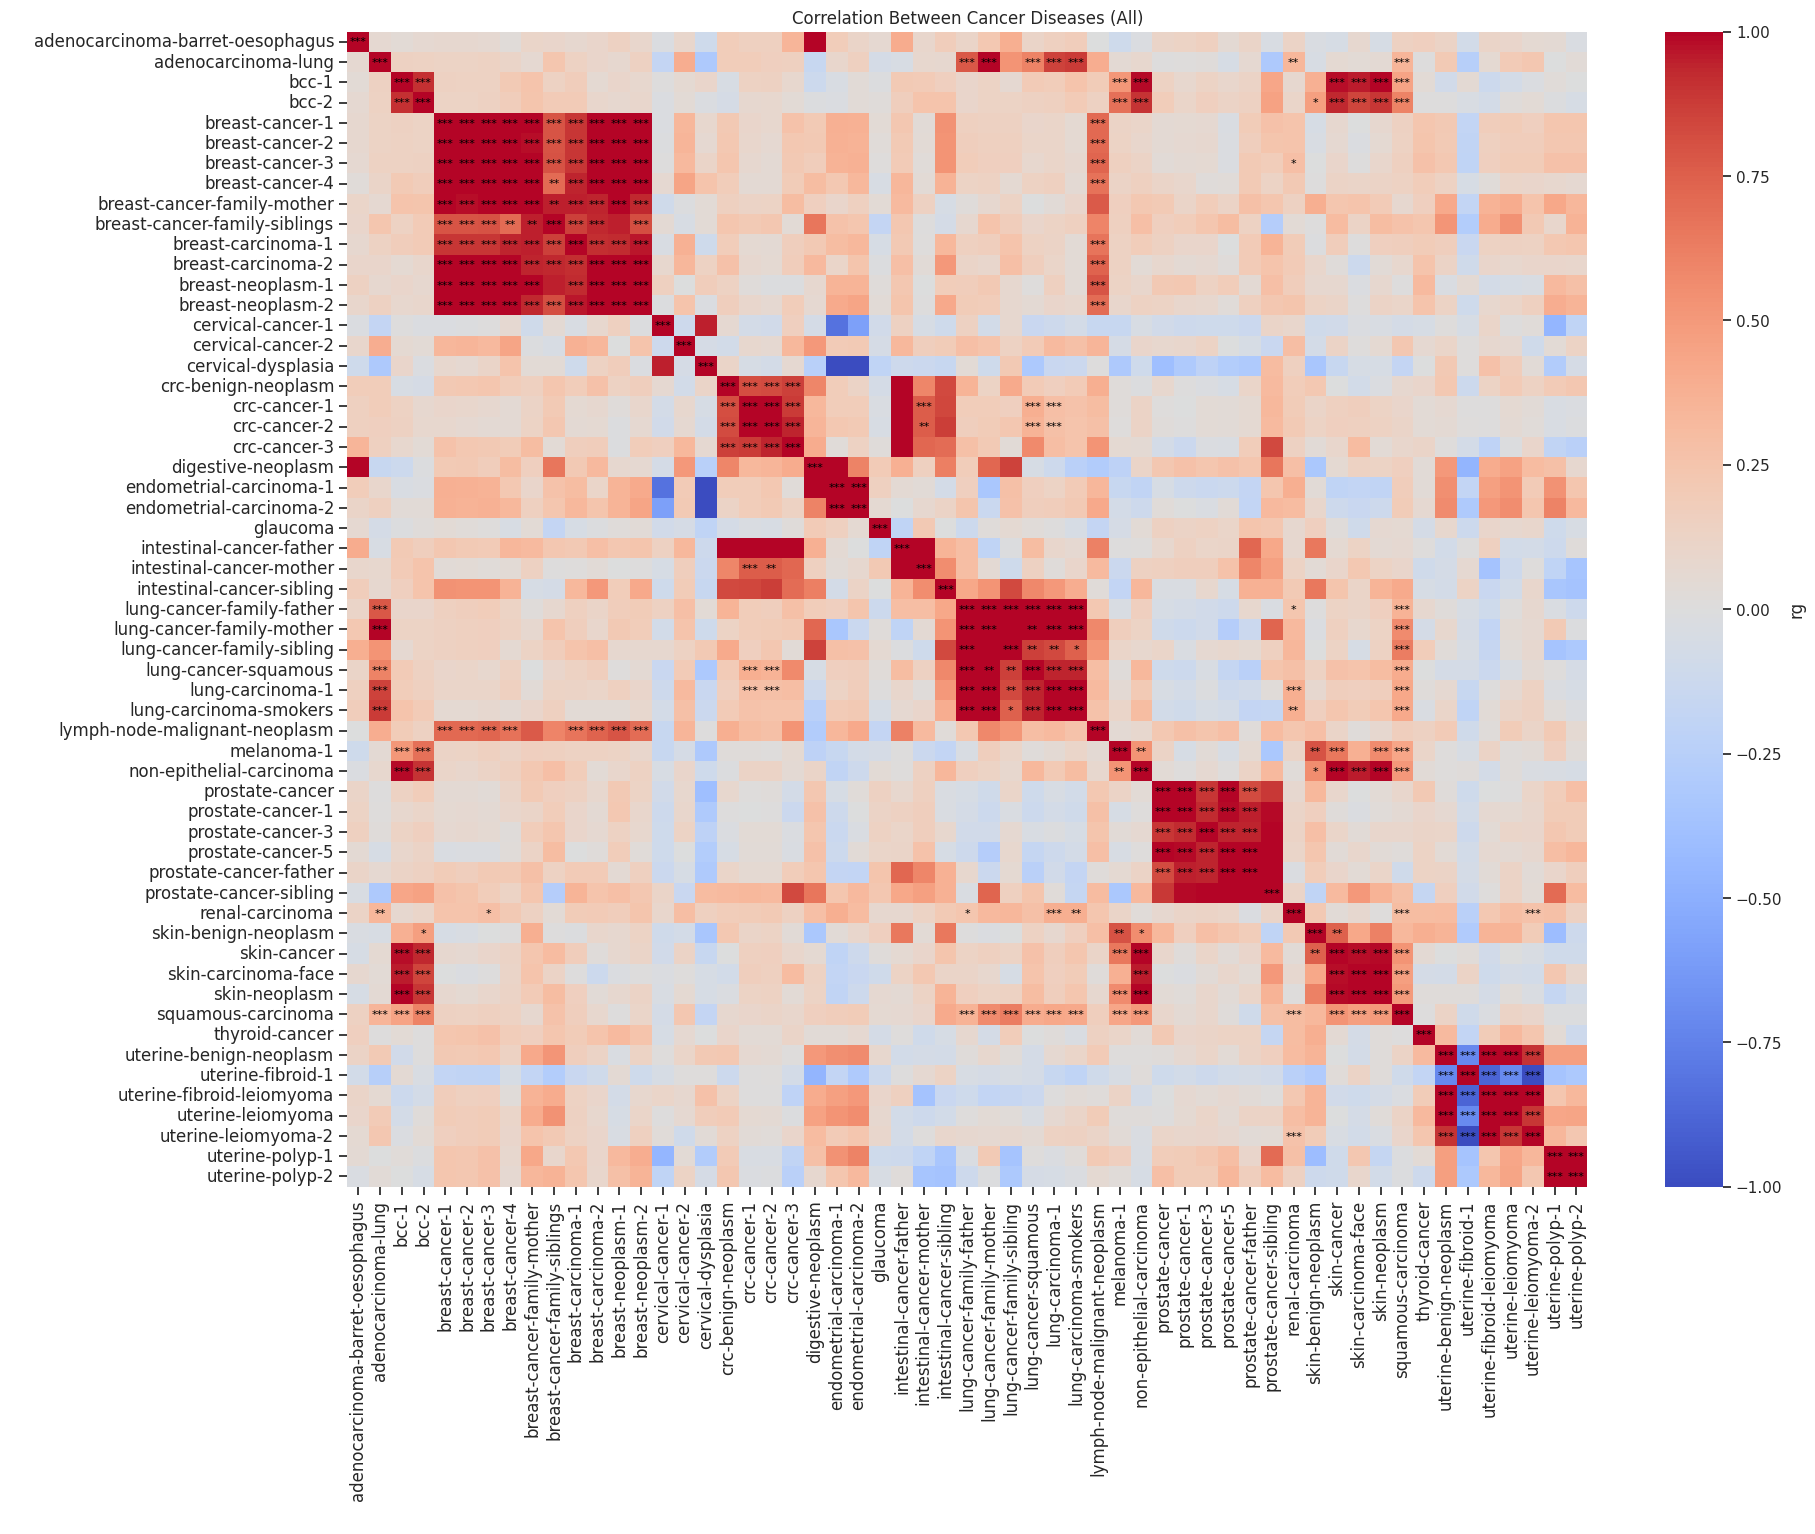

In [37]:
plot_heatmap_all(can_can_all_heatmap, 'Correlation Between Cancer Diseases (All)', " ", " ", "cancer_cancer_all_diseases")

## Network of disease interactions

In [38]:
len(ldsc_accepted_p)

2408

In [39]:
ldsc_accepted_p.drop(ldsc_accepted_p[ldsc_accepted_p["disease_1"] == ldsc_accepted_p["disease_2"]].index, inplace=True)

/tmp/ipykernel_106800/3418112961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldsc_accepted_p.drop(ldsc_accepted_p[ldsc_accepted_p["disease_1"] == ldsc_accepted_p["disease_2"]].index, inplace=True)


In [40]:
ldsc_accepted_p

,id_1,label_1,id_2,label_2,rg,se,z,p,h2_obs,h2_obs_se,...,type_1,selection_1,disease_1,disease_subtype_1,type_2,selection_2,disease_2,disease_subtype_2,p_corrected,p_bonf_rejected
6,GCST90042669,depression-family-father,GCST009979,mdd-1,0.7163,0.0900,7.9571,1.761700e-15,0.0780,0.0059,...,PSY,subtype-family,depression,family history,PSY,minor,major depression disorder,NaN,1.343472e-11,True
11,GCST90275152,autism-1,GCST003769,depression-symptoms,0.3689,0.0508,7.2557,3.994700e-13,0.0384,0.0033,...,PSY,minor,autism,NaN,PSY,minor,depression,symptoms,3.046358e-09,True
36,GCST010514,autism-2,GCST90042695,depression-family-sibling,0.3211,0.0625,5.1364,2.800900e-07,0.0129,0.0016,...,PSY,main,autism,NaN,PSY,subtype-family,depression,family history,2.135966e-03,True
53,GCST008465,ANN-PGC-2019,GCST90275157,schizo-sex-M1,0.2943,0.0578,5.0935,3.514800e-07,0.1207,0.0134,...,PSY,main,anorexia nervosa,anorexia nervosa,PSY,subtype,schizophrenia,sex,2.680386e-03,True
55,GCST90275149,ADHD-1,GCST90275155,mdd-5,0.5715,0.0329,17.3906,9.727800e-68,0.1192,0.0091,...,PSY,minor,attention deficit disorder,NaN,PSY,minor,major depression disorder,NaN,7.418420e-64,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15197,GCST90435631,lymph-node-malignant-neoplasm,GCST90041833,breast-neoplasm-2,0.7003,0.1158,6.0452,1.492600e-09,0.0046,0.0011,...,CAN,main,lymph node cancer,NaN,CAN,subtype,breast cancer,malignant neoplasm,1.138257e-05,True
15212,GCST90128471-all,SCZ-PGC-2022-all,GCST90435863,anxiety-3,0.4475,0.0582,7.6917,1.452400e-14,0.3442,0.0163,...,PSY,main,schizophrenia,NaN,PSY,minor,anxiety,NaN,1.107600e-10,True
15214,GCST009337,SCZ-PGC-2019,GCST010514,autism-2,0.2417,0.0459,5.2674,1.383600e-07,0.4160,0.0204,...,PSY,minor,schizophrenia,NaN,PSY,main,autism,NaN,1.055133e-03,True
15228,GCST90275153,mdd-age-sex-M1,GCST005902,depression-broad,0.6685,0.0427,15.6677,2.517100e-55,0.1072,0.0092,...,PSY,subtype,major depression disorder,"age, sex",PSY,subtype,depression,NaN,1.919540e-51,True


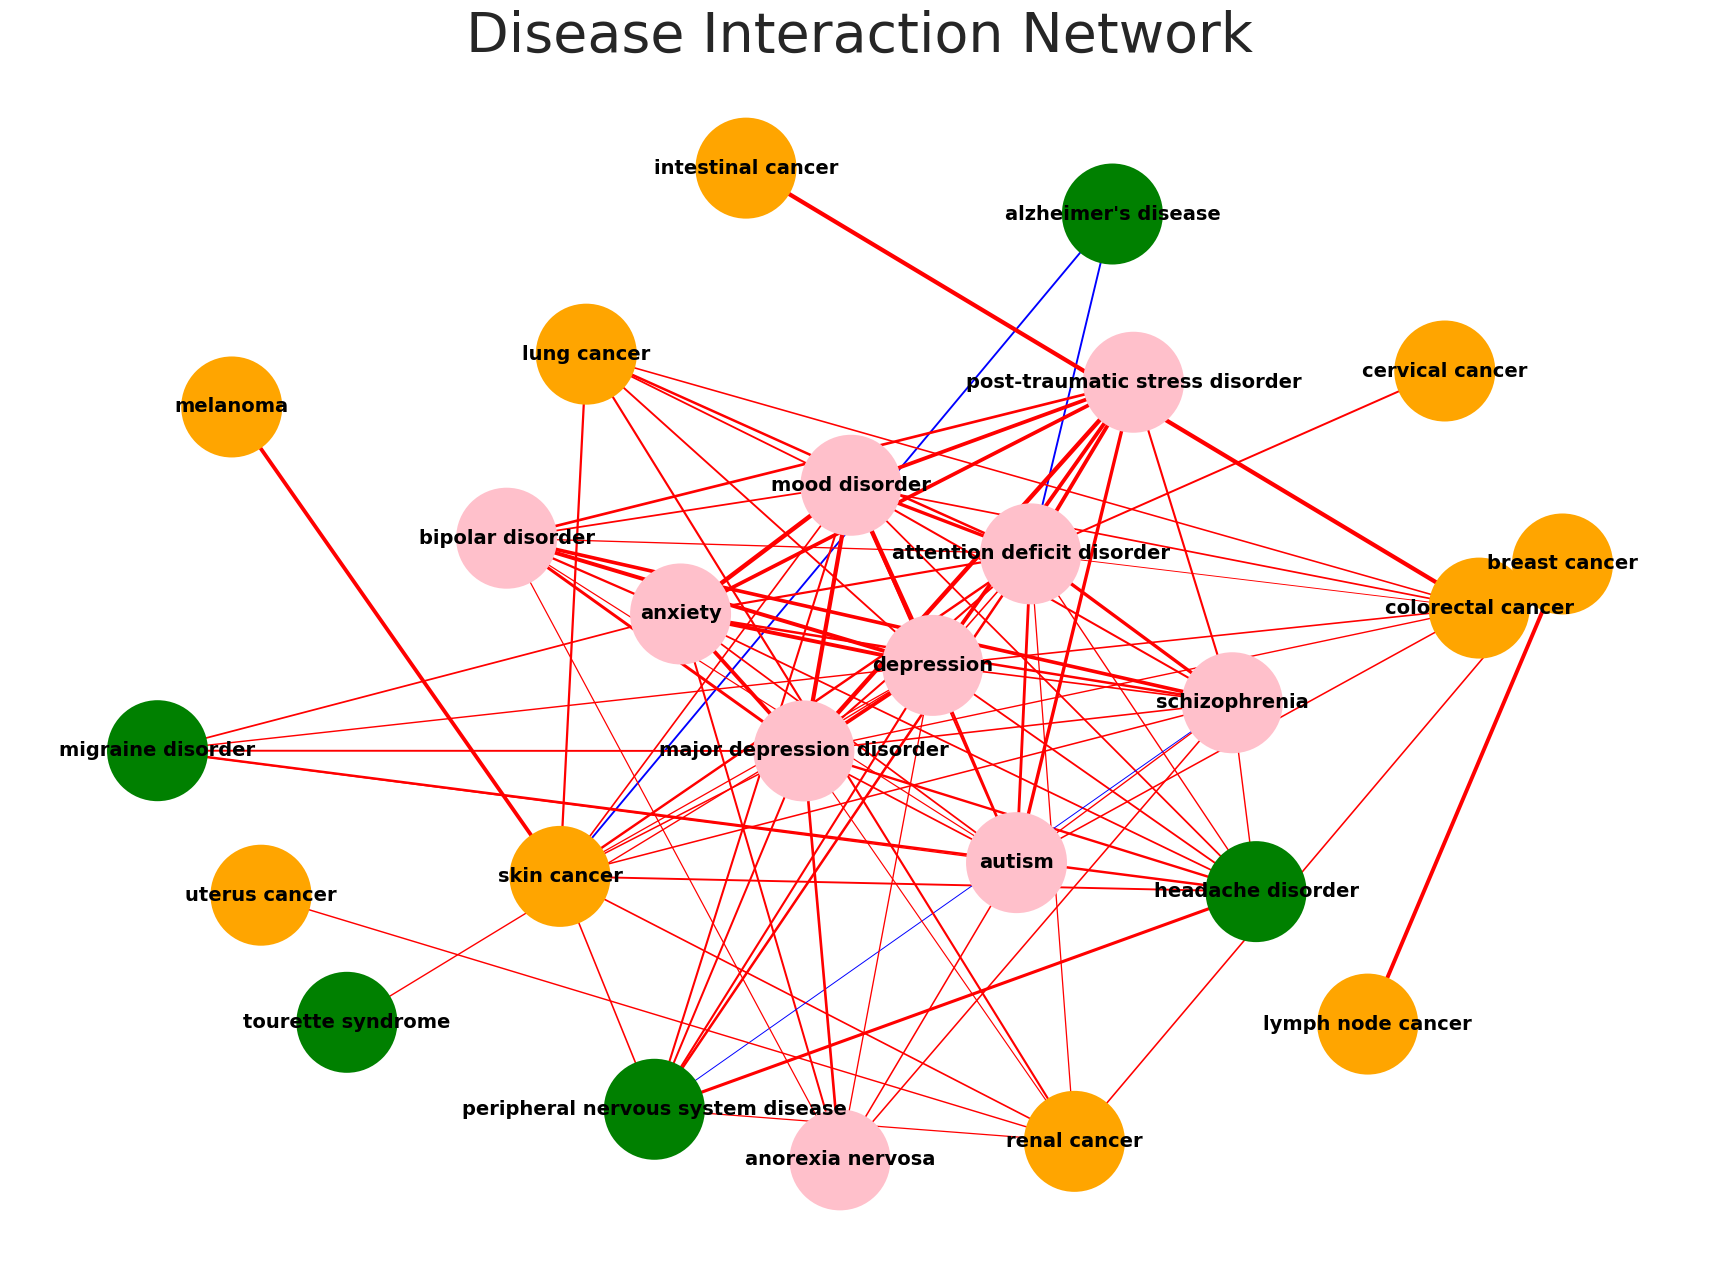

In [44]:
G = nx.Graph()

# Add nodes
for disease in set(ldsc_accepted_p['disease_1']).union(set(ldsc_accepted_p['disease_2'])):
    disease_type_1 = ldsc_accepted_p.loc[ldsc_accepted_p['disease_1'] == disease, 'type_1'].values
    disease_type_2 = ldsc_accepted_p.loc[ldsc_accepted_p['disease_2'] == disease, 'type_2'].values
    disease_type = disease_type_1[0] if len(disease_type_1) > 0 else disease_type_2[0] if len(disease_type_2) > 0 else 'Unknown'
    G.add_node(disease, type=disease_type)

# Add edges
for _, row in ldsc_accepted_p.iterrows():
    G.add_edge(row['disease_1'], row['disease_2'], weight=row['rg'], color='red' if row['rg'] > 0 else 'blue')

# Colors
type_colors = {'NEU': 'green', 'PSY': 'pink', 'CAN': 'orange', 'Unknown': 'gray'}
node_colors = [type_colors[G.nodes[node]['type']] for node in G.nodes]

edge_colors = [G[u][v]['color'] for u, v in G.edges]
edge_widths = [abs(G[u][v]['weight']) * 4 for u, v in G.edges]

# Draw
random_seed = 100
pos = nx.spring_layout(G, k=2.8, iterations=100, seed=random_seed)
# def custom_layout(G, weight='weight'):
#     pos = nx.spring_layout(G, k=1.5, iterations=50, weight=weight)
#     return pos

# pos = custom_layout(G)

plt.figure(figsize=(17,12))
nx.draw(G, pos, with_labels=True, linewidths=2, node_color=node_colors, edge_color=edge_colors, width=edge_widths, node_size=5000, font_size=14, font_weight="bold", font_color='black')
plt.title('Disease Interaction Network', fontsize=40)
# Save
plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/Accepted_Disease_Network_LDSC.png", bbox_inches="tight")
plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/Accepted_Disease_Network_LDSC.jpg", bbox_inches="tight")
plt.savefig(f"/home/maria/git/SOROLLA/Results/plots/Accepted_Disease_Network_LDSC.pdf", bbox_inches="tight")
